In [176]:
import pyreadr
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from shapely.ops import nearest_points
from shapely import affinity
from shapely.geometry import box
import math
import textwrap
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import pairwise_distances_argmin
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.stats import chi2
import numpy as np


# Import the states geofile
states = gpd.read_file("../data/shapefiles/ne_110m_admin_1_states_provinces.shp")

# Import ling data and location
ling_data = pd.read_csv("../data/lingData.txt", sep=r"\s+")
ling_location = pd.read_csv("../data/lingLocation.txt", sep=r"\s+")

#Import the main questions and answers
question = pyreadr.read_r(r"C:\Users\jcoll\Desktop\Everything\2026 Berkeley Fall\STAT 215A\stat-215a\lab2\data\question_data.RData")

# See what objects are inside the file
question.keys()

odict_keys(['ans.1', 'ans.10', 'ans.100', 'ans.101', 'ans.102', 'ans.103', 'ans.104', 'ans.105', 'ans.106', 'ans.107', 'ans.108', 'ans.109', 'ans.11', 'ans.110', 'ans.111', 'ans.112', 'ans.113', 'ans.114', 'ans.115', 'ans.116', 'ans.117', 'ans.118', 'ans.119', 'ans.12', 'ans.120', 'ans.121', 'ans.122', 'ans.13', 'ans.14', 'ans.15', 'ans.16', 'ans.17', 'ans.18', 'ans.19', 'ans.2', 'ans.20', 'ans.21', 'ans.22', 'ans.23', 'ans.24', 'ans.25', 'ans.26', 'ans.27', 'ans.28', 'ans.29', 'ans.3', 'ans.30', 'ans.31', 'ans.32', 'ans.33', 'ans.34', 'ans.35', 'ans.36', 'ans.37', 'ans.38', 'ans.39', 'ans.4', 'ans.40', 'ans.41', 'ans.42', 'ans.43', 'ans.44', 'ans.45', 'ans.46', 'ans.47', 'ans.48', 'ans.49', 'ans.5', 'ans.50', 'ans.51', 'ans.52', 'ans.53', 'ans.54', 'ans.55', 'ans.56', 'ans.57', 'ans.58', 'ans.59', 'ans.6', 'ans.60', 'ans.61', 'ans.62', 'ans.63', 'ans.64', 'ans.65', 'ans.66', 'ans.67', 'ans.68', 'ans.69', 'ans.7', 'ans.70', 'ans.71', 'ans.72', 'ans.73', 'ans.74', 'ans.75', 'ans.76', 'a

In [177]:
print(states.shape, ling_data.shape, ling_location.shape)
ling_location.head(5)
ling_data.head(5)
len(ling_data)


(51, 122) (47471, 73) (781, 471)


47471

# Introduction

Things to potentially include in your introduction:

-   Describe the problem of interest and put your analysis in the domain
    context. Read the introduction of the two Nerbonne and Kertzschmar
    papers for some help here.

-   What do you aim to learn from this data?

-   Outline what you will be doing in the rest of the report/analysis

John Nerbonne and William Kretzschmar describe dialectometry as "the measurement of dialect differences, i.e. linguistic differences whose distribution is determined primarily by geography" (Nerbonne & Kretzschmar, 2003). Linguistic differences across geographic regions have been studied in many ways, and both Nerboonne & Kretzschmar 2003 and Nerbonne & Kretzschmar 2006 outline attempts to statistically describe the correlation between dialect and geography. They further delve into a few methods that identify other ways to explain linguistic variations that have ultimately pushed the field forward. <br>
In this report, we will primarily focus on the connection between dialects and geography, using the idea of dialetometry to analyze results from the 2003 Harvard Dialect Survey (http://dialect.redlog.net/). From the survey results, we would like to know if there is a real difference in the way that individuals say/pronounce/communicate a certain word or idea between geographical contexts in the United States. We wish to know if there are distinct geographic groups who pronounce certain words differently, if these groups can be used to predict how words are said, and if these groups relate to surrounding geography. <br>
Through the exploration of geography and dialect groupings, we will be analyzing how well different statistical techniques are performing. Considering the size of the data, we will continue with an assessment of dimension reduction techniques, PCA consideration, and two different clustering methods which will be further evaluated by using data perturbations. Lastly, we will consider the three realms of data science--data, algorithms and analysis, and future data--and will analyze our results through the lens of each.



# The Data {#data}

-   What is the data that you will be looking at?
-   Provide a brief overview of the data
-   How is this data relevant to the problem of interest? In other
    words, make the link between the data and the domain problem <br>

In is report we analyze the 2003 Harvard Dialect Survey. This survey asks a series of 121 questions. Each question explores how a participant would pronounce a word, say a phrase, or refer to an item/idea. The survey had a total of 30,934 respondants of all ages, ranging from under 13 years old to over 70 years old. There is at least one respondant from every US state. For this report, we will specifically be looking at lexical differences as opposed to phonetic differences, and therefore, only look at 50-121. No extra step is needed for this, since the data set gives has already dropped questions 1-50. <br>

For most of the lexical questions, the questions usually began with "what do you call..." or "Would you say...' and then it would end with a description or way to say something. Each question usually had many responses labeled a, b, c, etc. In our dataset, a is coded as 1, b is coded as 2, etc. The location of each respondant was also taken. Then, for every question, each answer was tabulated and a map of where each answer was selected can be seen on the website http://dialect.redlog.net/. <br>

This data will be extremely helpful in determining for linking dialects to geography. By mapping the data, we will be able to visually see where these words/sayings are used. Then, we can see if our statistical tools will be helpful in determining a true link between dialect and geography, which tools work, which to avoid, and the limitations of each.




## Data Cleaning

To clean the data, we first standardized the geographic labels, then resolved any location mismatches using spatial checks, then imputed missing coordinates, and lastly filtered out unresolvable or empty responses. The original input was 47,471 respondents. We ended up dropping 1,453 rows (~3.06% of the dataset), leaving a final cleaned sample of 46,018 respondents.

The first thing we did was standardize the state abbreviations and map the two-letter state abbreviations to their names, so that we could cross-reference them with the states shapefile. We also normalized city names for grouping comparisons. Then we filtered invalid and foreign respondents: we removed rows where the state was listed as XX, as well as non-US cities. We also dropped 91 rows with invalid or unrecognized state abbreviations that did not have a city to fall back on. Then, for respondents with city entries, we checked whether their ZIP code matched one of the known ZIP codes in the data set belonging to the same state, and filled in the missing city from there. We did this for 404 rows. Then we dropped 88 rows with a missing city that could not be verified or backfilled by a ZIP code.

Lastly, we made sure that all of the respondents' locations fell within a US state boundary. We noticed that New York City needed a correction because the state polygons overlapped, so that New York City boroughs were falling inside New Jersey's geometry. We therefore explicitly assigned those respondents NY as their state abbreviation. We also cleaned 387 rows where the state was mismatched. If the respondent's city was reported in the existing validated set, we could use the valid data to correct the state. We ended up trusting the self-reported city and state values over the ZIP code values, since the GSIs were the ones who created the ZIP codes and input the latitude and longitude. So, for cities and states that did not match their latitude, longitude, or ZIP code, we moved those responses to the correct city and state. That was not possible for 59 of the rows, and they had to be removed.

There were also some points that were outside of the state boundaries. We simply moved them to the median coordinates of their reported city. For coastal or border cities without a validated city median, we snapped them back to the nearest boundary edge of their reported state's polygon, and we dropped six rows with invalid geometry or that were very far from the state's geometry. We then used coordinates matching ZIP codes to fill in missing coordinates for 160 rows, and we dropped 94 rows whose location we could not recover. The last step was dropping the 1,032 respondents who answered none of the survey questions.

It is important to note that Michigan's geometry is a little strange, due to its territory being close to the water. If there was more time, we would fix this issue with the state's polygon.


In [178]:
# Check data type
ling_data.dtypes.to_list()
ling_location.dtypes.to_list()
states.dtypes.to_list()
# --> All types seem to be ok, but note the int32s vs int64s
    # Not a problem for the math, but good to note
    # Also note that there are both POLYGONS and MULTIPOLYGONS
    # in the 'geometry' column

# Check for invalid responses
# Make sure that there are no more than 26 (number of letters in 
# alphabet) options in the question columns
list(ling_data.nunique())
# --> ok

# Check for NaNs
list(ling_data.isna().sum())
# --> 540 NaNs in the City column
#     Some City's are functionally incorrect/do not exist
# --> 3 NaNs in State column
#     Some States are labeled XX 

# There are some Lats and Longs that may not be trustworthy since either City and/or State 
# is not coded and we do not know how these were dealt with in processing, may be best to drop

# Lets make sure that lat/longs match up to the states given

# --- Map state abbreviations to full names ------------------------------
abbr_to_name = {
    'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas',
    'CA': 'California', 'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware',
    'DC': 'District of Columbia', 'FL': 'Florida', 'GA': 'Georgia', 'HI': 'Hawaii',
    'ID': 'Idaho', 'IL': 'Illinois', 'IN': 'Indiana', 'IA': 'Iowa',
    'KS': 'Kansas', 'KY': 'Kentucky', 'LA': 'Louisiana', 'ME': 'Maine',
    'MD': 'Maryland', 'MA': 'Massachusetts', 'MI': 'Michigan', 'MN': 'Minnesota',
    'MS': 'Mississippi', 'MO': 'Missouri', 'MT': 'Montana', 'NE': 'Nebraska',
    'NV': 'Nevada', 'NH': 'New Hampshire', 'NJ': 'New Jersey', 'NM': 'New Mexico',
    'NY': 'New York', 'NC': 'North Carolina', 'ND': 'North Dakota', 'OH': 'Ohio',
    'OK': 'Oklahoma', 'OR': 'Oregon', 'PA': 'Pennsylvania', 'RI': 'Rhode Island',
    'SC': 'South Carolina', 'SD': 'South Dakota', 'TN': 'Tennessee', 'TX': 'Texas',
    'UT': 'Utah', 'VT': 'Vermont', 'VA': 'Virginia', 'WA': 'Washington',
    'WV': 'West Virginia', 'WI': 'Wisconsin', 'WY': 'Wyoming'
}

# Standardize state codes, then add full state names
ling_data['STATE'] = ling_data['STATE'].str.strip().str.upper()
ling_data['STATE_NAME'] = ling_data['STATE'].map(abbr_to_name)

print("Ling_data length: ", len(ling_data))

# First lets make sure that the data with a valid States and Cities
# Have a lat/long that falls within that state

states_simpl = states[['name', 'geometry']]

# Rows with a recognized state and a city
known = ling_data['STATE_NAME'].notna() & ling_data['CITY'].notna()
# Rows without a recognized state and city
print("Number of rows with unknown CITY/STATE: ", len(ling_data[~known]))


# We definitely do not want to trust rows where there is no city AND no state
# Dropping rows where STATE is XX and City is NaN

drop = ling_data['STATE'].eq('XX') & ling_data['CITY'].isna()
ling_data1 = ling_data[~drop]
print("Dropped rows where State was XX and City is NaN, dropped: ", (len(ling_data) - len(ling_data1))/len(ling_data) *100, "%")
print("That is ", len(ling_data)-len(ling_data1), " rows")



ling_data[~known]
#Ling_data1 dropped rows where State is XX and City is NaN

# In the dataset, respondents only noted their City and their State. If there was a missing state, but a valid city,
# this would be enough for the GSI's to code in the zipcode and the lat/long values.
# However, if there was a missing city and just a valid state, GSI's would have to guess where the person is from within the state.
# Therefore, the zipcodes may be randomly or arbitrarily assigned. 
# Although the lat and long pf a point with an unknown city may remain within the given state, due to the large size of states, 
# there may be enough variation to disrupt clustering.
# In the dataset, missing data only accounts for 1.4% of the dataset. Therefore, we feel comfortable removing these locations where 
# GSIs had to guess 



Ling_data length:  47471
Number of rows with unknown CITY/STATE:  651
Dropped rows where State was XX and City is NaN, dropped:  0.10111436455941523 %
That is  48  rows


,ID,CITY,STATE,ZIP,Q050,Q051,Q052,Q053,Q054,Q055,...,Q111,Q115,Q117,Q118,Q119,Q120,Q121,lat,long,STATE_NAME
51,55,NaN,MO,65552,4,1,3,1,1,2,...,2,1,1,6,3,2,3,37.545213,-92.173230,Missouri
56,60,NaN,CA,95050,7,2,3,2,2,2,...,2,1,1,7,1,5,1,37.347791,-121.951317,California
140,152,fhhjdhj,HA,52353,8,2,1,1,1,1,...,2,1,3,4,1,2,1,41.300042,-91.697434,NaN
194,208,NaN,XX,8003,0,0,0,0,0,0,...,0,0,0,0,0,0,0,39.879713,-74.971900,NaN
281,296,NaN,NY,10956,4,2,3,2,2,2,...,2,1,1,7,1,2,1,41.145495,-73.994901,New York
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47333,49923,NaN,MO,64112,1,1,1,2,1,1,...,2,1,1,4,3,2,7,39.037605,-94.595377,Missouri
47366,49957,NaN,IL,61761,4,2,2,2,2,2,...,1,1,1,7,1,2,1,40.515485,-88.986299,Illinois
47420,50011,NaN,MD,21755,4,2,2,1,2,2,...,2,1,1,7,1,2,1,39.372496,-77.558693,Maryland
47421,50013,NaN,XX,93003,4,2,2,1,2,2,...,2,1,1,7,1,2,1,34.268736,-119.224909,NaN


In [179]:
bad_codes = ['HA', 'TE', 'OM', 'MM', 'NT', 'SE', 'WN', 'UK', 'XX', 'NO',
             'BC', 'IO', 'RS', 'NB', 'N.', 'NS', 'QC', 'ON', 'UP', 'AB',
             '94', 'TZ', 'DA', 'NF', 'C)', 'KA', 'IE', 'NZ', 'TC', 'MG',
             'MU', 'PL', '00', 'IS', 'M', 'WB', 'PR', '!L', 'FA', 'TA', 'IT']

remain_unknown = ling_data1[~known]

remain_unknown[remain_unknown['STATE'].isin(bad_codes)]['CITY'].unique()

# Cities that are clearly outside the US
foreign_cities = [
    'expatriate', 'SomewherebetweenScotlandand', 'portoalegre', 'WoodsHarbour',
    'Montreal', 'Toronto', 'NorthYork', 'Fredericton', 'Uppsala', 'Didsbury',
    'Madrid', 'Singapore', 'Rossendale', 'Freiburg', 'Auckland',
    'KrapkowicePoland', 'port-au-prince', 'calcuttaindia', 'Palmanova',
]

n_before = len(ling_data1)
ling_data2 = ling_data1[~ling_data1['CITY'].isin(foreign_cities)]
print("Dropped rows that were outside of the US, dropped", (len(ling_data) - len(ling_data2))/len(ling_data) *100, "%")
print("That is another", n_before-len(ling_data2), " rows")

# Rebuild for the updated data
known = ling_data2['STATE_NAME'].notna() & ling_data2['CITY'].notna()
remain_unknown = ling_data2[~known]
print("Rows with unknown CITY/STATE remaining:", len(remain_unknown))

#Ling_data2
remain_unknown


Dropped rows that were outside of the US, dropped 0.17484358871732217 %
That is another 35  rows
Rows with unknown CITY/STATE remaining: 583


C:\Users\jcoll\AppData\Local\Temp\ipykernel_61792\2451892894.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  remain_unknown = ling_data1[~known]


,ID,CITY,STATE,ZIP,Q050,Q051,Q052,Q053,Q054,Q055,...,Q111,Q115,Q117,Q118,Q119,Q120,Q121,lat,long,STATE_NAME
51,55,NaN,MO,65552,4,1,3,1,1,2,...,2,1,1,6,3,2,3,37.545213,-92.173230,Missouri
56,60,NaN,CA,95050,7,2,3,2,2,2,...,2,1,1,7,1,5,1,37.347791,-121.951317,California
140,152,fhhjdhj,HA,52353,8,2,1,1,1,1,...,2,1,3,4,1,2,1,41.300042,-91.697434,NaN
281,296,NaN,NY,10956,4,2,3,2,2,2,...,2,1,1,7,1,2,1,41.145495,-73.994901,New York
326,344,NaN,NJ,7712,4,2,2,2,2,2,...,2,1,6,7,1,6,3,40.232713,-74.031432,New Jersey
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47151,49738,NaN,TX,78258,9,1,1,2,2,2,...,2,1,5,6,1,5,2,29.649797,-98.504065,Texas
47333,49923,NaN,MO,64112,1,1,1,2,1,1,...,2,1,1,4,3,2,7,39.037605,-94.595377,Missouri
47366,49957,NaN,IL,61761,4,2,2,2,2,2,...,1,1,1,7,1,2,1,40.515485,-88.986299,Illinois
47420,50011,NaN,MD,21755,4,2,2,1,2,2,...,2,1,1,7,1,2,1,39.372496,-77.558693,Maryland


In [180]:
# Drop rows where STATE_NAME doesn't make sense (missing, XX, or unrecognized code)
n_before = len(ling_data2)
ling_data3 = ling_data2[ling_data2['STATE_NAME'].notna()]
print(f"Dropped {n_before - len(ling_data3)} rows with an invalid state")

# Rebuild for the updated data
known = ling_data3['STATE_NAME'].notna() & ling_data3['CITY'].notna()
remain_unknown = ling_data3[~known]
print("Rows with unknown CITY/STATE remaining:", len(remain_unknown))


Dropped 91 rows with an invalid state
Rows with unknown CITY/STATE remaining: 492


In [181]:
# Use the zipcodes from the known data to fill in the CITY column
# THIS MAKES THE ASSUMPTION THAT THE GSI'S WERE CORRECT IN THEIR 
# APPLICATION OF THE ZIPCODE COLUMN, IT DOES ALLOW FOR MORE COMPLETE DATA,
# BUT THESE COULD HAVE BEEN GUESSES
# Reference: rows that have both a valid state and a city
ref = ling_data3[known]

zip_city = ref.groupby('ZIP').agg(
    zip_city=('CITY', lambda s: s.mode().iloc[0]),
    zip_state=('STATE', lambda s: s.mode().iloc[0]),
    n_ref=('CITY', 'size'),
)

# Look up each remaining row's ZIP
cand = remain_unknown[['ID', 'STATE', 'ZIP']].join(zip_city, on='ZIP')

found = cand['zip_city'].notna()
same_state = cand['zip_state'] == cand['STATE']
fill = found & same_state

print("Rows missing a city:", len(cand))
print("ZIP found, same state (will fill):", fill.sum())
print("ZIP found, different state (left alone):", (found & ~same_state).sum())
print("ZIP not found (left alone):", (~found).sum())

ling_data3 = ling_data3.copy()   # make it its own table before editing

idx = cand.index[fill]
ling_data3.loc[idx, 'CITY'] = cand.loc[fill, 'zip_city']
ling_data3.loc[idx, 'loc_fix'] = 'city_from_zip'

# Rebuild for the updated data
known = ling_data3['STATE_NAME'].notna() & ling_data3['CITY'].notna()
remain_unknown = ling_data3[~known]
print("Rows still missing a city:", len(remain_unknown))

remain_unknown

Rows missing a city: 492
ZIP found, same state (will fill): 404
ZIP found, different state (left alone): 3
ZIP not found (left alone): 85
Rows still missing a city: 88


,ID,CITY,STATE,ZIP,Q050,Q051,Q052,Q053,Q054,Q055,...,Q115,Q117,Q118,Q119,Q120,Q121,lat,long,STATE_NAME,loc_fix
51,55,NaN,MO,65552,4,1,3,1,1,2,...,1,1,6,3,2,3,37.545213,-92.173230,Missouri,NaN
870,927,NaN,MD,21750,7,1,2,2,2,2,...,1,1,7,3,1,1,39.692614,-78.216915,Maryland,NaN
1249,1333,NaN,CA,94924,0,0,0,0,0,0,...,1,1,7,1,1,5,37.907675,-122.702018,California,NaN
1755,1876,NaN,CT,6384,8,2,3,2,2,2,...,1,1,7,1,5,1,41.578700,-71.856680,Connecticut,NaN
1766,1890,NaN,ME,90210,4,2,2,2,2,2,...,1,1,7,1,2,1,34.088808,-118.406125,Maine,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44707,47247,NaN,VA,22443,4,2,2,2,2,2,...,1,5,1,1,2,2,38.226530,-76.974424,Virginia,NaN
45035,47584,NaN,IA,50230,4,1,1,1,1,2,...,1,1,4,2,1,3,42.303222,-93.453439,Iowa,NaN
45578,48135,NaN,SD,57020,9,2,2,1,1,1,...,3,5,6,3,2,7,43.672525,-96.817576,South Dakota,NaN
47021,49606,NaN,SC,29827,9,2,3,1,2,2,...,1,1,7,1,2,3,32.963048,-81.240523,South Carolina,NaN


In [182]:
# Drop remaining rows with no city: too uncertain without manual checks
# Zip code cannot be verified with known data
n_before = len(ling_data3)
ling_data4 = ling_data3[known]
print(f"Dropped {n_before - len(ling_data4)} rows with no city that could be filled from ZIP")

# Total dropped so far, relative to the original data, ling_data
n_total = len(ling_data) - len(ling_data4)
print(f"Total dropped so far: {n_total} rows ({n_total / len(ling_data):.2%} of the dataset)")

# Every remaining row should now have a valid state and a city!
known = ling_data4['STATE_NAME'].notna() & ling_data4['CITY'].notna()
print("Rows with unknown CITY/STATE:", (~known).sum())

Dropped 88 rows with no city that could be filled from ZIP
Total dropped so far: 262 rows (0.55% of the dataset)
Rows with unknown CITY/STATE: 0


In [183]:
# Fix rows whose coordinates fall in a different State (the 1136 rows)
# Three independent pieces of evidence:
# Rules:
# If CITY agrees with coordinates + ZIP, not state -> STATE was wrong: correct
# If CITY agrees with reported state   -> ZIP/lat/lon was wrong: move point to the city
# If CITY agrees with neither          -> keep reported state (trust the person), flag

ling_data_city = ling_data4.copy()
name_to_abbr = {v: k for k, v in abbr_to_name.items()}

# --- 1. State check on the current data ----------------------------------
gdf = gpd.GeoDataFrame(
    ling_data_city,
    geometry=gpd.points_from_xy(ling_data_city['long'], ling_data_city['lat']),
    crs="EPSG:4326"
).to_crs(states.crs)

joined = gpd.sjoin(gdf, states_simpl, how='left', predicate='within')
assert joined.index.is_unique

outside_all = joined['name'].isna()
mismatch = ~outside_all & (joined['name'] != joined['STATE_NAME'])

# Adding a buffer distance (km) from each flagged point to its REPORTED state's polygon
# This change is becuase smaller states sometimes were confused (NY/NJ)
states_m = states_simpl.to_crs(5070).set_index('name') 
pts_m = gdf.to_crs(5070)

flagged = joined.index[mismatch | outside_all]
dist_km = pd.Series(
    [pts_m.loc[i, 'geometry'].distance(states_m.loc[joined.loc[i, 'STATE_NAME'], 'geometry']) / 1000
     for i in flagged],
    index=flagged)

# Points within 5 km of their reported state count as a match
near = pd.Series(False, index=joined.index)
near[flagged] = dist_km < 5

mismatch = mismatch & ~near
outside_all = outside_all & ~near

print("Rows:", len(joined))
print("Inside (or within 5 km of) the reported state:", (~outside_all & ~mismatch).sum())
print("In a different state:", mismatch.sum())
print("Outside every polygon:", outside_all.sum())

c:\Users\jcoll\miniconda3\envs\215a\Lib\site-packages\shapely\measurement.py:81: RuntimeWarning: invalid value encountered in distance
  return lib.distance(a, b, **kwargs)


Rows: 47209
Inside (or within 5 km of) the reported state: 45619
In a different state: 387
Outside every polygon: 1203


In [184]:
# First fixing the 387 that fell into a different state
# We will trust the CITY column as long as the city is valid
# This is becuase the CITY corresponds with the zipcode, which gives lat/long
# Correct STATE only if the city exists in the state the point falls in
# AND does not exist in the reported state

# Simplified city names so all cases match
ling_data_city['city_key'] = ling_data_city['CITY'].str.lower().str.replace(r'[^a-z]', '', regex=True)

# New York and New Jersey are consistently confused in the dataset,
# because the simplified polygons place parts of NYC inside NJ.
# NYC boroughs are always in New York:
nyc_boroughs = ['statenisland', 'manhattan', 'brooklyn', 'queens', 'bronx']

nyc_rows = ling_data_city['city_key'].isin(nyc_boroughs)
ling_data_city.loc[nyc_rows, 'STATE'] = 'NY'
ling_data_city['STATE_NAME'] = ling_data_city['STATE'].map(abbr_to_name)

# Valid cities known to be in each state
valid = ling_data_city.loc[joined.index[~outside_all & ~mismatch]]
ref_pairs = set(zip(valid['STATE'], valid['city_key']))

# NYC names always count as existing in NY
nyc_places = nyc_boroughs + ['newyork', 'newyorkcity', 'nyc']
ref_pairs |= {('NY', c) for c in nyc_places}

# --- State each mismatched point falls in, and the state the person reported ---
coord_state = joined.loc[mismatch, 'name'].map(name_to_abbr)
city_key = ling_data_city.loc[coord_state.index, 'city_key']
reported_state = ling_data_city.loc[coord_state.index, 'STATE']

# City exists in the coordinate state, but not in the reported state
city_valid = [(s, c) in ref_pairs and (r, c) not in ref_pairs
              for s, c, r in zip(coord_state, city_key, reported_state)]
to_fix = coord_state[city_valid]

# Preview before applying
#display(ling_data_city.loc[to_fix.index, ['CITY', 'STATE', 'ZIP']].assign(corrected_to=to_fix))

ling_data_city.loc[to_fix.index, 'STATE'] = to_fix
ling_data_city['STATE_NAME'] = ling_data_city['STATE'].map(abbr_to_name)

print("NYC borough rows set to NY:", nyc_rows.sum())
print("Mismatched rows:", len(coord_state))
print("Corrected:", len(to_fix))
print("Kept reported state:", len(coord_state) - len(to_fix))

NYC borough rows set to NY: 467
Mismatched rows: 387
Corrected: 38
Kept reported state: 349


In [185]:
# Now we look at the 349 points where the reported state was kept
# Trust the respondant's CITY and STATE over the ZIP-based lat/long:
# move points to the typical location of their reported city

kept = coord_state.index.difference(to_fix.index)
to_move = kept

k = ling_data_city.loc[to_move, ['CITY', 'STATE', 'city_key', 'ZIP', 'lat', 'long']]

# Typical location of each city, from validated rows
city_loc = valid.groupby(['STATE', 'city_key']).agg(
    city_lat=('lat', 'median'),
    city_long=('long', 'median'),
)

k = k.join(city_loc, on=['STATE', 'city_key'])
can_move = k['city_lat'].notna()

# Apply
idx = k.index[can_move]
ling_data_city.loc[idx, 'lat'] = k.loc[can_move, 'city_lat']
ling_data_city.loc[idx, 'long'] = k.loc[can_move, 'city_long']

ling_data_city['moved_to_city'] = False
ling_data_city.loc[idx, 'moved_to_city'] = True

print("Rows considered:", len(k))
print("Moved to their reported city:", can_move.sum())
print("City not found among validated rows (left as is):", (~can_move).sum())

Rows considered: 349
Moved to their reported city: 290
City not found among validated rows (left as is): 59


In [186]:
# For the cities that were mislabeled, they would have to be manually adjusted. In the interest of time, 
# We will be dropping these 59 columns, which is only 0.1% of the dataset
drop_idx = k.index[~can_move]

n_before = len(ling_data_city)
ling_data_final = ling_data_city.drop(index=drop_idx)
print(f"Dropped {n_before - len(ling_data_final)} rows whose city couldn't be located without manual check")

# Total dropped so far, relative to the original data
n_total = len(ling_data) - len(ling_data_final)
print(f"Total dropped so far: {n_total} rows ({n_total / len(ling_data):.2%} of the dataset)")

Dropped 59 rows whose city couldn't be located without manual check
Total dropped so far: 321 rows (0.68% of the dataset)


In [187]:
# Now look at the 1203 that fell outside of a given polygon

# Points outside every polygon: move to their reported city where possible
to_move = joined.index[outside_all].intersection(ling_data_final.index)

k = ling_data_final.loc[to_move, ['CITY', 'STATE', 'city_key', 'ZIP', 'lat', 'long']]
k = k.join(city_loc, on=['STATE', 'city_key'])
can_move = k['city_lat'].notna()

idx = k.index[can_move]
ling_data_final.loc[idx, 'lat'] = k.loc[can_move, 'city_lat']
ling_data_final.loc[idx, 'long'] = k.loc[can_move, 'city_long']
ling_data_final.loc[idx, 'moved_to_city'] = True   # adds to the earlier flags

print("Rows considered:", len(k))
print("Moved to their reported city:", can_move.sum())
print("City not found among validated rows:", (~can_move).sum())


Rows considered: 1203
Moved to their reported city: 846
City not found among validated rows: 357


In [188]:
# Most cities that were outside a polygon were coastal cities. 
# For the coastal cities that did not have a validated row with a point within a polygon, 
# We will be snapping each of the points to the nearest edge of the polygon within the state
# of that city based on the STATE column.

# Rows whose city wasn't found, that have coordinates
nf = k.index[~can_move]
nf = nf[ling_data_final.loc[nf, ['lat', 'long']].notna().all(axis=1)]

# Reported-state polygons in meters, shrunk 100 m so snapped points land inside
states_in = states_simpl.to_crs(5070).set_index('name')['geometry'].buffer(-100)

pts = gpd.GeoSeries(
    gpd.points_from_xy(ling_data_final.loc[nf, 'long'], ling_data_final.loc[nf, 'lat']),
    index=nf, crs="EPSG:4326"
).to_crs(5070)

# Snap each point to the nearest spot inside its reported state
snapped, dist_snap = {}, {}
for i in nf:
    poly = states_in.get(ling_data_final.loc[i, 'STATE_NAME'])
    p = pts[i]
    if poly is None or not (abs(p.x) < 1e10 and abs(p.y) < 1e10):   # no polygon, or bad coordinates
        continue
    q = nearest_points(poly, p)[0]
    snapped[i] = q
    dist_snap[i] = p.distance(q) / 1000

dist_snap = pd.Series(dist_snap)
print("Snap distances (km):")
print(dist_snap.describe())

# Only snap points within 50 km of their reported state
ok = dist_snap.index[dist_snap < 50]
new_pts = gpd.GeoSeries([snapped[i] for i in ok], index=ok, crs=5070).to_crs("EPSG:4326")


# Apply
ling_data_final.loc[ok, 'lat'] = new_pts.y
ling_data_final.loc[ok, 'long'] = new_pts.x
ling_data_final['snapped_to_edge'] = False
ling_data_final.loc[ok, 'snapped_to_edge'] = True

print("Candidates:", len(nf))
print("Snapped (within 50 km):", len(ok))
print("Not snapped (too far, bad coordinates, or no polygon):", len(nf) - len(ok))


Snap distances (km):
count     103.000000
mean       61.270265
std       436.493897
min         5.919069
25%        10.107348
50%        11.849198
75%        16.620700
max      4442.804339
dtype: float64
Candidates: 103
Snapped (within 50 km): 97
Not snapped (too far, bad coordinates, or no polygon): 6


In [189]:
# Drop rows that couldn't be snapped (too far, bad coordinates, or no polygon)
not_snapped = nf.difference(ok)

n_before = len(ling_data_final)
ling_data_final = ling_data_final.drop(index=not_snapped)
print(f"Dropped {n_before - len(ling_data_final)} rows that couldn't be snapped")

n_total = len(ling_data) - len(ling_data_final)
print(f"Total dropped so far: {n_total} rows ({n_total / len(ling_data):.2%} of the dataset)")

Dropped 6 rows that couldn't be snapped
Total dropped so far: 327 rows (0.69% of the dataset)


In [190]:
# Restore leading zeros (2193 -> '02193'), then check for exactly 5 digits
zip_str = ling_data_final['ZIP'].astype(str).str.zfill(5)
bad_zip = ~zip_str.str.fullmatch(r'\d{5}') | zip_str.eq('00000')

In [191]:
# Now we are nearing our final cleaned dataframe
# Use zipcodes to see if remaining missing lat/longs can be filled
# Drop if it would take a manual input

# Define rows with coordinates 'has' and missing coordinates 'nc'
has = ling_data_final[ling_data_final["lat"].notna()]
nc = ling_data_final[ling_data_final["lat"].isna()]

# Fill missing coordinates from other rows with the same ZIP
zip_loc = has.groupby('ZIP')[['lat', 'long']].median()

fill = nc[['ZIP']].join(zip_loc, on='ZIP')
filled = fill['lat'].notna()

ling_data_final.loc[fill.index[filled], ['lat', 'long']] = fill.loc[filled, ['lat', 'long']].values
print("Filled from ZIP:", filled.sum())

# Drop rows that still have no coordinates
no_coords = ling_data_final[['lat', 'long']].isna().any(axis=1)
n_before = len(ling_data_final)
ling_data_final = ling_data_final[~no_coords]
print(f"Dropped {n_before - len(ling_data_final)} rows with no way to locate them")

n_total = len(ling_data) - len(ling_data_final)
print(f"Total dropped so far: {n_total} rows ({n_total / len(ling_data):.2%} of the dataset)")

Filled from ZIP: 160
Dropped 94 rows with no way to locate them
Total dropped so far: 421 rows (0.89% of the dataset)


In [ ]:
# Clean up the final df by dropping old columns
ling_data_final = ling_data_final.drop(columns=['loc_fix', 'city_key', 'moved_to_city', 'snapped_to_edge'])

# Also! Lets make sure to drop rows where a respondant did not answer ANY
# of the questions

# Clean up the final df by dropping old columns
ling_data_final = ling_data_final.drop(
    columns=['loc_fix', 'city_key', 'moved_to_city', 'snapped_to_edge']
)

# Identify respondents who did not answer ANY questions
q_cols = ling_data_final.filter(regex=r'^Q\d+$').columns
no_answers = (ling_data_final[q_cols] == 0).all(axis=1)

# Perform filtering
n_before = len(ling_data_final)
ling_data_final = ling_data_final[~no_answers]

# Calculate metrics
dropped_empty = n_before - len(ling_data_final)
total_dropped = len(ling_data) - len(ling_data_final)
drop_pct = (total_dropped / len(ling_data)) * 100
final_count = len(ling_data_final)

# Create summary table for report output
summary_df = pd.DataFrame(
    [
        {
            'Metric': 'Dropped (No Answers)',
            'Count': f'{dropped_empty:,}',
            'Percentage': f'{(dropped_empty / len(ling_data)):.2%}',
        },
        {
            'Metric': 'Total Dropped So Far',
            'Count': f'{total_dropped:,}',
            'Percentage': f'{drop_pct:.2f}%',
        },
        {
            'Metric': 'Final Sample Size',
            'Count': f'{final_count:,}',
            'Percentage': f'{(final_count / len(ling_data)):.2%}',
        },
    ]
)

# Display formatted table
display(summary_df)

Final number of rows to work with:  47050
Dropped 1032 respondents with no answers
Total dropped so far: 1453 rows (3.06% of the dataset)
Final number of rows to work with:  46018


,ID,CITY,STATE,ZIP,Q050,Q051,Q052,Q053,Q054,Q055,...,Q111,Q115,Q117,Q118,Q119,Q120,Q121,lat,long,STATE_NAME
0,1,Boise,ID,83704,4,1,3,2,3,1,...,2,1,6,7,3,2,3,43.631230,-116.287161,Idaho
1,2,Pittsfield,MA,1201,4,2,3,2,2,2,...,2,1,1,7,1,1,3,42.453840,-73.254003,Massachusetts
2,3,Burlington,VT,5401,4,1,2,2,2,2,...,2,1,4,7,1,2,1,44.484038,-73.221265,Vermont
3,4,Easton,PA,18042,7,1,1,2,2,2,...,1,1,3,7,1,2,1,40.681798,-75.220820,Pennsylvania
4,5,Bedford,MA,1730,8,2,3,1,2,2,...,3,1,5,8,1,1,1,42.496679,-71.275046,Massachusetts
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47466,50060,Wilmington,NC,28443,4,2,1,2,2,2,...,2,1,1,7,3,2,3,34.407677,-77.652381,North Carolina
47467,50061,Cincinnati,OH,45231,7,2,3,2,2,2,...,3,1,1,6,2,6,6,39.242608,-84.545305,Ohio
47468,50062,BayCity,MI,48706,1,1,1,2,2,2,...,3,1,1,7,1,2,3,43.607523,-83.916202,Michigan
47469,50063,seattle,WA,98103,4,2,1,2,2,2,...,3,1,1,7,1,2,3,47.671346,-122.341662,Washington


## Exploratory Data Analysis {#data-exploration}

-   This is where you compare pairs of questions with discussion and
    plots.

In [193]:
# Choose a question: 
# Choosing 65: glowing bugs
# Choosing 66: mini lobster

# Creatures!
# Glowing bugs
q65 = question['ans.65']
print(q65)

# Mini lobster
q66 = question['ans.66']
q66

# Adding more varaibles for broader check later
# Rolling bug
q74 = question['ans.74']
# Long-legged Spider Bug
q67 = question['ans.67']

# Q065: Glowing bugs
q65_map = {
    1: 'lightning bug',
    2: 'firefly',
    3: 'I use lightning bug and firefly interchangeably',
    4: 'peenie wallie',
    5: 'I have no word for this',
    6: 'other',
}

# Q066: Mini lobster
q66_map = {
    1: 'crawfish',
    2: 'crayfish',
    3: 'craw',
    4: 'crowfish',
    5: 'crawdad',
    6: 'mudbug',
    7: 'I have no word for this critter',
    8: 'other',
}

# Q067: Long-legged spider-like creature
q67_map = {
    1: 'daddy long leg(s)',
    2: 'daddy big legs',
    3: 'daddy (bug)',
    4: 'father longlegs',
    5: 'granddaddy',
    6: 'daddy graybeard',
    7: 'daddy spider',
    8: 'harvestman',
    9: 'moskeet spider',
    10: 'pointer',
    11: 'shepherd spider',
    12: 'other',
}

# Q074: Little creature that rolls into a ball
q74_map = {
    1: 'pill bug',
    2: 'doodle bug',
    3: 'potato bug',
    4: 'roly poly',
    5: 'sow bug',
    6: 'basketball bug',
    7: 'twiddle bug',
    8: 'roll-up bug',
    9: 'wood louse',
    10: 'millipede',
    11: 'centipede',
    12: 'I know what this creature is, but have no word for it',
    13: 'I have no idea what this creature is',
    14: 'other',
}

   qnum ans.let    per                                               ans
0    65       a  29.07                                    lightning bug 
1    65       b  30.43                                          firefly 
2    65       c  39.81  I use lightning bug and firefly interchangeably 
3    65       d   0.02                                    peenie wallie 
4    65       e   0.35                          I have no word for this 
5    65       f   0.32                                            other 


In [194]:
ling_data_creatures = ling_data_final[['ID', 'CITY', 'STATE', 'ZIP', 'lat', 'long', 'Q065', 'Q066', 'Q067', 'Q074']]

ling_data_creatures['Q065_ans'] = ling_data_creatures['Q065'].map(q65_map)
ling_data_creatures['Q066_ans'] = ling_data_creatures['Q066'].map(q66_map)
ling_data_creatures['Q067_ans'] = ling_data_creatures['Q067'].map(q67_map)
ling_data_creatures['Q074_ans'] = ling_data_creatures['Q074'].map(q74_map)


ling_data_creatures

,ID,CITY,STATE,ZIP,lat,long,Q065,Q066,Q067,Q074,Q065_ans,Q066_ans,Q067_ans,Q074_ans
0,1,Boise,ID,83704,43.631230,-116.287161,2,2,1,1,firefly,crayfish,daddy long leg(s),pill bug
1,2,Pittsfield,MA,1201,42.453840,-73.254003,2,1,1,13,firefly,crawfish,daddy long leg(s),I have no idea what this creature is
2,3,Burlington,VT,5401,44.484038,-73.221265,2,1,1,3,firefly,crawfish,daddy long leg(s),potato bug
3,4,Easton,PA,18042,40.681798,-75.220820,3,2,1,14,I use lightning bug and firefly interchangeably,crayfish,daddy long leg(s),other
4,5,Bedford,MA,1730,42.496679,-71.275046,3,1,1,5,I use lightning bug and firefly interchangeably,crawfish,daddy long leg(s),sow bug
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47466,50060,Wilmington,NC,28443,34.407677,-77.652381,3,1,1,4,I use lightning bug and firefly interchangeably,crawfish,daddy long leg(s),roly poly
47467,50061,Cincinnati,OH,45231,39.242608,-84.545305,1,5,1,4,lightning bug,crawdad,daddy long leg(s),roly poly
47468,50062,BayCity,MI,48706,43.607523,-83.916202,3,2,1,4,I use lightning bug and firefly interchangeably,crayfish,daddy long leg(s),roly poly
47469,50063,seattle,WA,98103,47.671346,-122.341662,3,2,1,4,I use lightning bug and firefly interchangeably,crayfish,daddy long leg(s),roly poly


In [195]:
def response_table(df, col):
    """Count and percent of each answer, most common first."""
    counts = df[col].value_counts()
    return pd.DataFrame({
        'count': counts,
        'percent': (counts / counts.sum() * 100).round(2),
    })

print("Question 65: Glowing bug")
display(response_table(ling_data_creatures, 'Q065_ans'))

print("Question 66: Mini lobster")
display(response_table(ling_data_creatures, 'Q066_ans'))

Question 65: Glowing bug


,count,percent
Q065_ans,,
I use lightning bug and firefly interchangeably,17430,38.09
lightning bug,15643,34.18
firefly,12348,26.98
I have no word for this,174,0.38
other,124,0.27
peenie wallie,42,0.09


Question 66: Mini lobster


,count,percent
Q066_ans,,
crawfish,18237,39.91
crayfish,12632,27.65
crawdad,10710,23.44
I have no word for this critter,2135,4.67
other,1866,4.08
mudbug,49,0.11
craw,38,0.08
crowfish,25,0.05


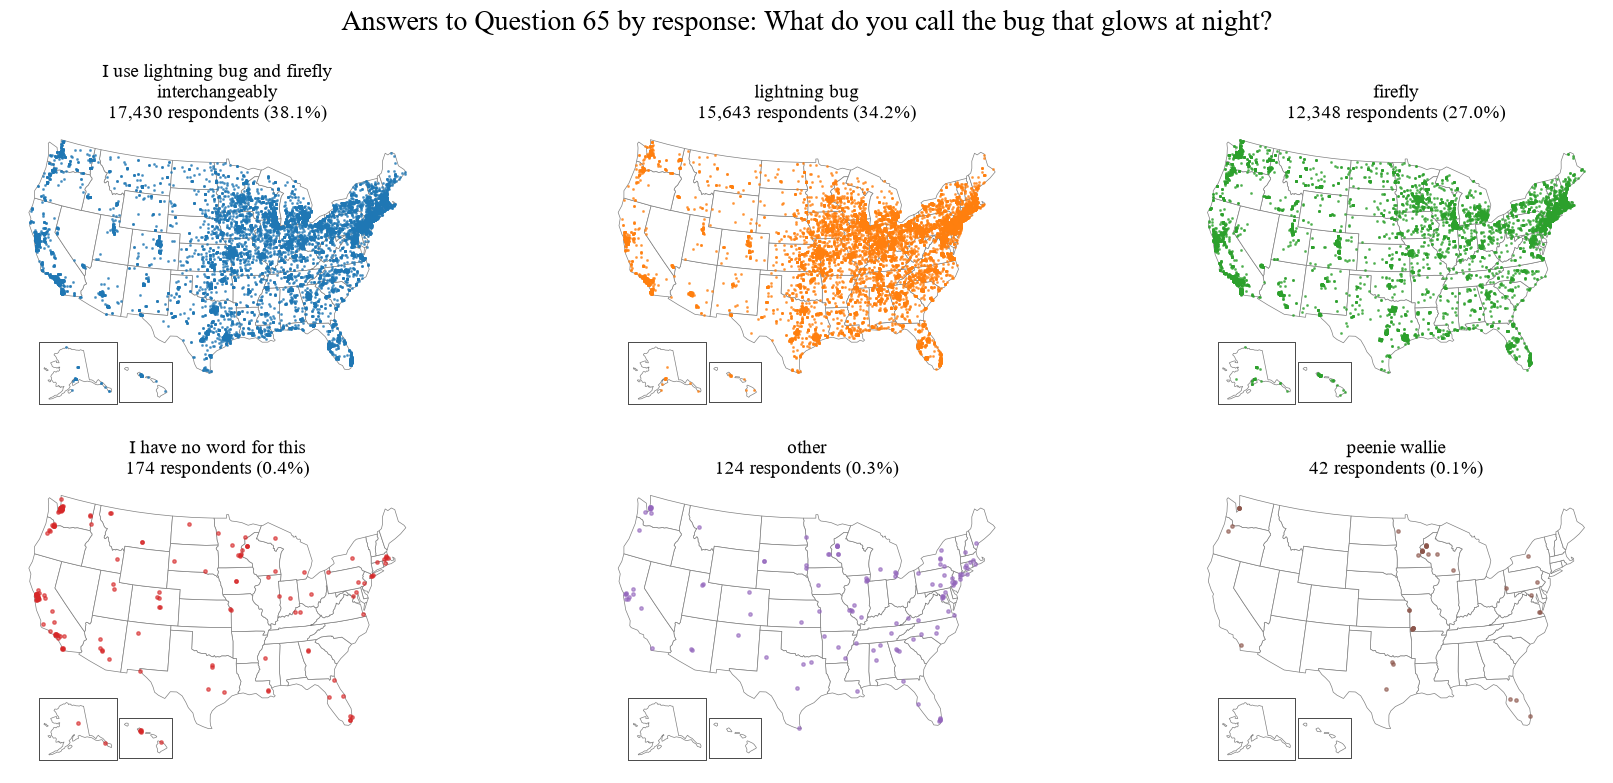

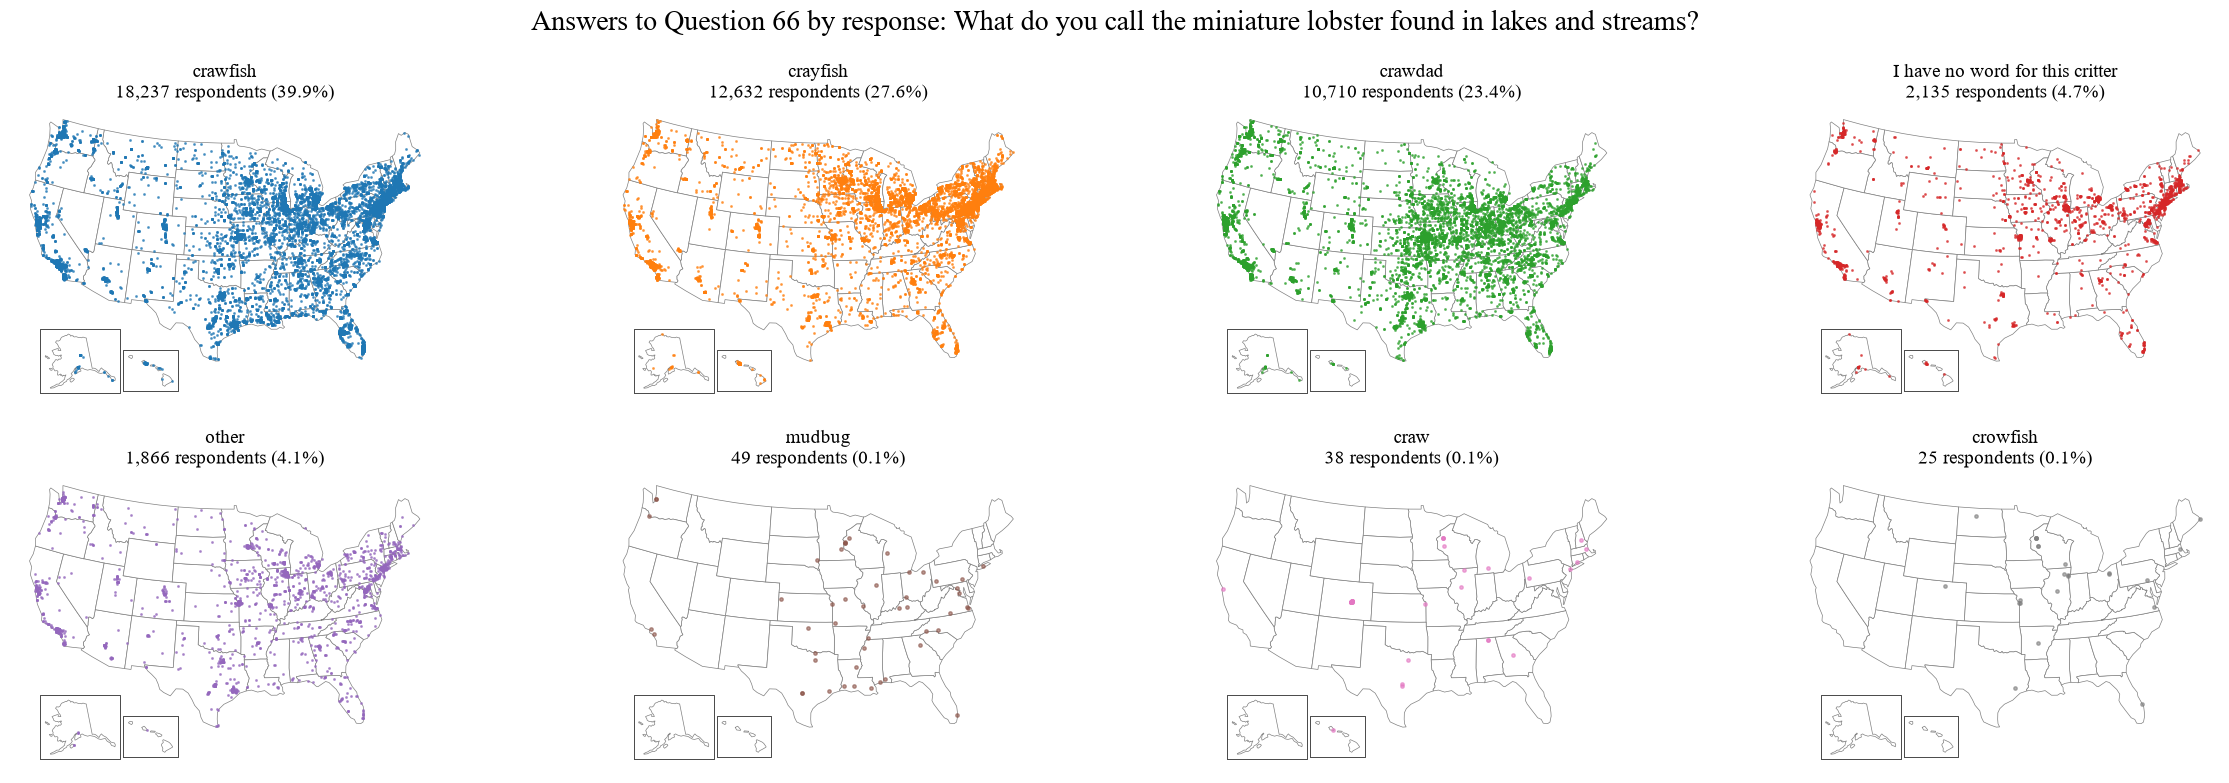

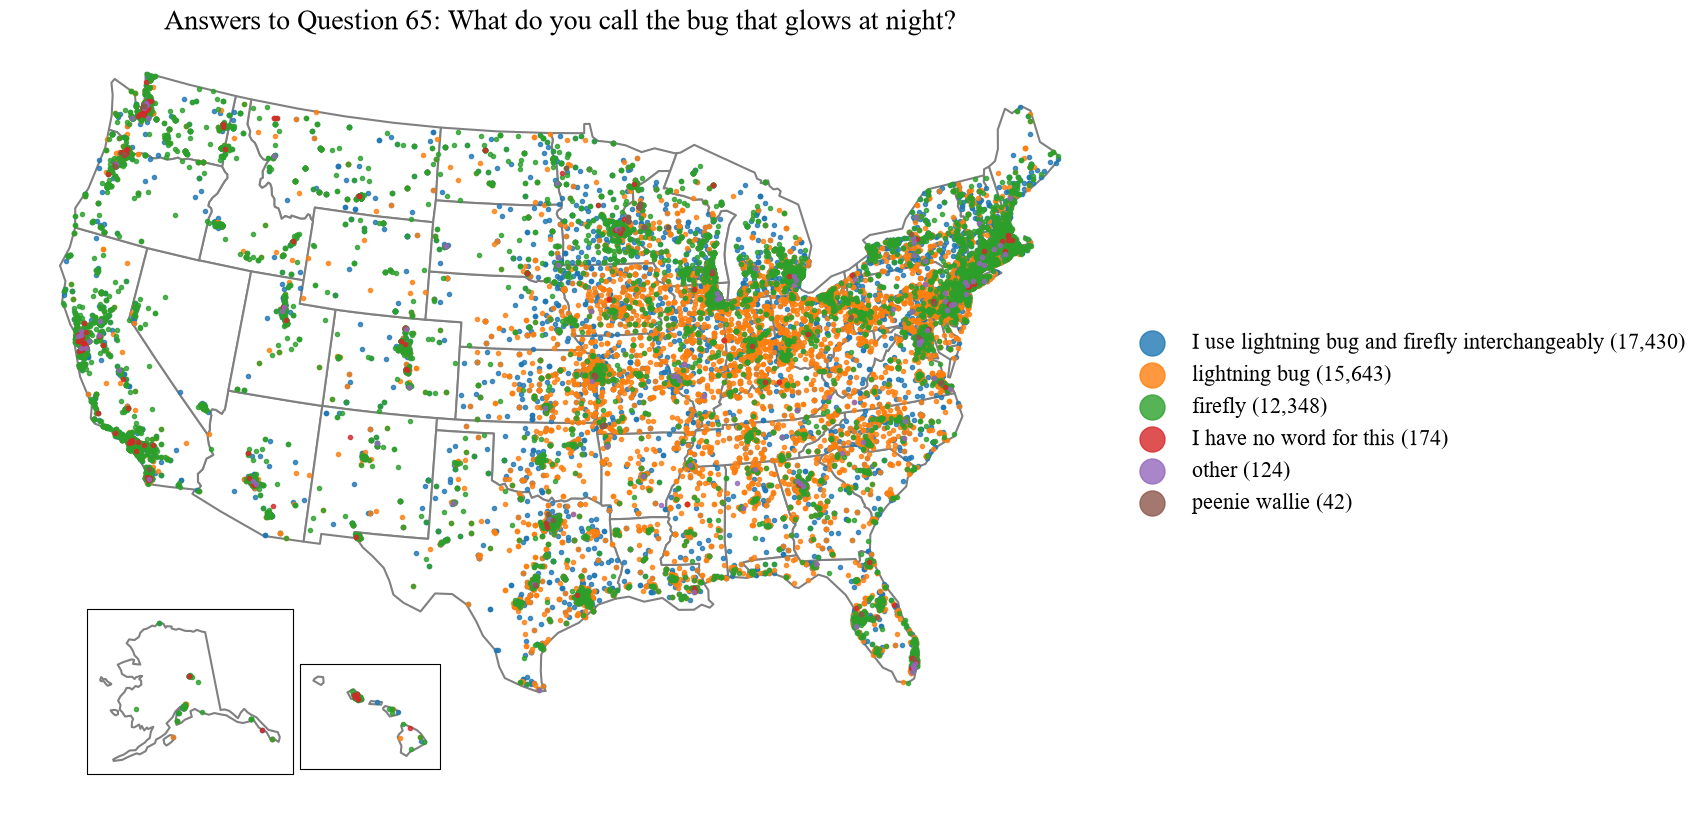

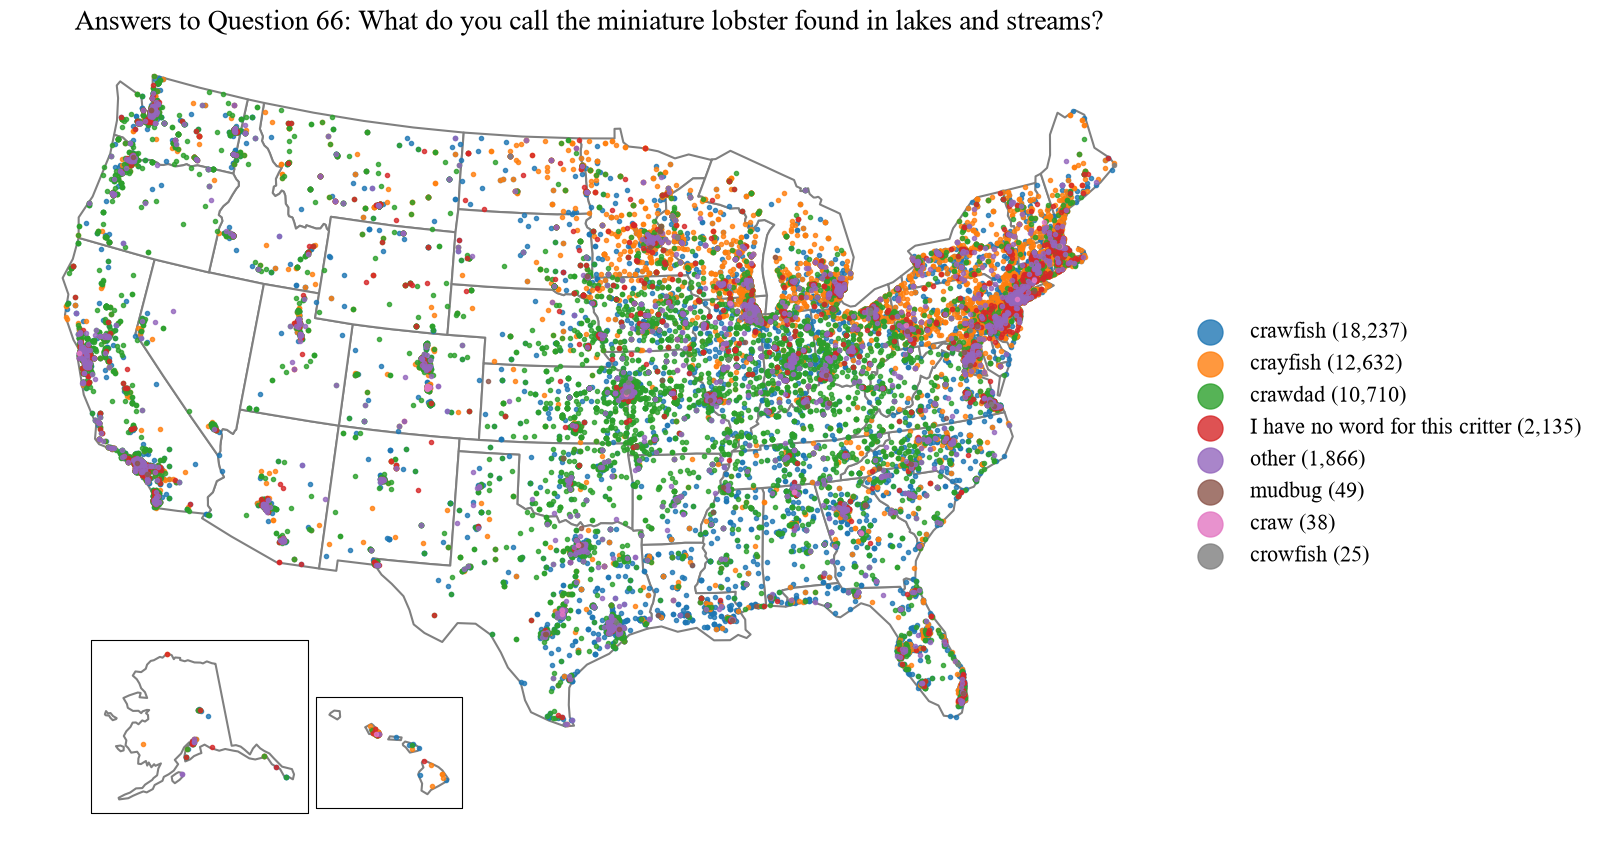

In [196]:
# Map responses for each question
# Grab points
creatures_gdf = gpd.GeoDataFrame(
    ling_data_creatures,
    geometry=gpd.points_from_xy(ling_data_creatures['long'], ling_data_creatures['lat']),
    crs="EPSG:4326"
).to_crs(states.crs)

# Set font/size
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 14

# Meter-based units
states_m = states_simpl.to_crs(5070).copy()
pts_m = creatures_gdf.to_crs(5070).copy()

# Grab just alaska and hawaii, since they are stranger sizes/
# may interfere with legend
ak = states_m[states_m['name'] == ('Alaska')]
hi = states_m[states_m['name'] == ('Hawaii')]

# Their respondents' points
ak_pts = pts_m[pts_m['STATE'] == 'AK']
hi_pts = pts_m[pts_m['STATE'] == 'HI']

# Everything Else: contiguous US
conus = states_m[~states_m['name'].isin(['Alaska', 'Hawaii'])]
conus_pts = pts_m[~pts_m['STATE'].isin(['AK', 'HI'])]

# Bounds of the contiguous, used to place Alaska and Hawaii
minx, miny, maxx, maxy = conus.total_bounds
w, h = maxx - minx, maxy - miny

# Alaska and Hawaii's projection, so they appear upright instead of rotated
AK_CRS = 'EPSG:3338'   # Alaska Albers
HI_CRS = ('+proj=aea +lat_1=8 +lat_2=18 +lat_0=13 +lon_0=-157 '
          '+x_0=0 +y_0=0 +datum=NAD83 +units=m +no_defs')   # Hawaii Albers
          # Keeps Hawaii seen and upright

def place(state_part, pt_part, crs, scale, target_x, target_y, pad=60_000):
    """Reproject Hawaii and Alaska, put these states in their own box."""
    s = state_part.to_crs(crs).copy()
    p = pt_part.to_crs(crs).copy()
    x0, y0, x1, y1 = s.total_bounds
    cx, cy = (x0 + x1) / 2, (y0 + y1) / 2

    def mv(g):
        g = affinity.scale(g, scale, scale, origin=(cx, cy))
        return affinity.translate(g, target_x - cx, target_y - cy)

    s['geometry'] = s.geometry.apply(mv)
    p['geometry'] = p.geometry.apply(mv)
    s = s.set_crs(5070, allow_override=True)
    p = p.set_crs(5070, allow_override=True)

    bx0, by0, bx1, by1 = s.total_bounds
    frame = box(bx0 - pad, by0 - pad, bx1 + pad, by1 + pad)
    return s, p, frame

# Alaska: 35% size, below the West Coast
ak_m, ak_pts_m, ak_box = place(ak, ak_pts, AK_CRS, 0.35, minx + 0.13 * w, miny)

# Hawaii: actual size, to the right of Alaska
hi_m, hi_pts_m, hi_box = place(hi, hi_pts, HI_CRS, 1.0, minx + 0.31 * w, miny - 0.04 * h)

# Put everything back together
states_m = gpd.GeoDataFrame(pd.concat([conus, ak_m, hi_m]), crs=5070)
pts_m = gpd.GeoDataFrame(pd.concat([conus_pts, ak_pts_m, hi_pts_m]), crs=5070)
boxes_m = gpd.GeoSeries([ak_box, hi_box], crs=5070)

# Map it
def map_answers(gdf, col, title, caption=None):
    """One point per respondent, colored by answer. Rarer answers are drawn on top."""
    answered = gdf[gdf[col].notna()]
    order = answered[col].value_counts().index # rank most common first
    colors = plt.cm.tab10.colors

    fig, ax = plt.subplots(figsize=(16, 9))
    states_m.plot(ax=ax, color='white', edgecolor='grey', linewidth=1.5)
    boxes_m.boundary.plot(ax=ax, color='black', linewidth=0.8)

    for i, ans in enumerate(order):
        pts = answered[answered[col] == ans]
        pts.plot(ax=ax, color=colors[i % 10], markersize=9, alpha=0.8,
                 label=f"{ans} ({len(pts):,})", zorder=3 + i)

    # Legend outside the map, so it can't cover anything
    ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5),
              markerscale=6, fontsize=16, frameon=False)
    ax.set_title(title, fontsize=20)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()


def map_answers_grid(gdf, col, title, ncols=3):
    """One small map per answer, in the same colors and order as the big map."""
    answered = gdf[gdf[col].notna()]
    order = answered[col].value_counts().index      # same order as the big map
    colors = plt.cm.tab10.colors
    nrows = math.ceil(len(order) / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
    axes = axes.flatten()

    for i, ans in enumerate(order):
        ax = axes[i]
        pts = answered[answered[col] == ans]

        states_m.plot(ax=ax, color='white', edgecolor='grey', linewidth=0.5)
        boxes_m.boundary.plot(ax=ax, color='black', linewidth=0.5)

        # Bigger dots for rare answers so a few dozen points are still visible
        size = 1.3 if len(pts) > 1000 else 6
        pts.plot(ax=ax, color=colors[i % 10], markersize=size, alpha=0.6, zorder=3)

        label = textwrap.fill(ans, 35)    # wrap long answers onto two lines
        ax.set_title(f"{label}\n{len(pts):,} respondents ({len(pts) / len(answered):.1%})",
                     fontsize=14)
        ax.set_axis_off()

    # Hide any empty panels in the last row
    for ax in axes[len(order):]:
        ax.set_visible(False)

    fig.suptitle(title, fontsize=20)
    plt.tight_layout()
    plt.show()

map_answers_grid(pts_m, 'Q065_ans',
                 'Answers to Question 65 by response: What do you call the bug that glows at night?',
                 ncols=3)
map_answers_grid(pts_m, 'Q066_ans',
                 'Answers to Question 66 by response: What do you call the miniature lobster found in lakes and streams?',
                 ncols=4)


map_answers(pts_m, 'Q065_ans',
            'Answers to Question 65: What do you call the bug that glows at night?')
map_answers(pts_m, 'Q066_ans',
            'Answers to Question 66: What do you call the miniature lobster found in lakes and streams?')

When looking at the two graphs that map the answers to questions 65 and 66, we see that in both maps, distinct geographical groups begin to form. Broadly, considering just those who answered the question, we can see that many responses are clustered along the north eastern part of the US. Then, we see another cluster of responses along the west coast. Then, we also see clusters around capitol cities such as Pheonix AZ, Denver CO, Salt Lake City UT, and Albequerque NM. This trend aligns with any searched population density map of the US. So, upon first glance it seems that responses are quite widespread across the US and align well with the expected US population. <br>

The next trend that we see are certain colors having higher frequencies in certain areas. In the glowing bug question, we see the highest concentration of the term "firefly" (27%) in cities and along the top of north eastern states. We also see it heavily used on the west coast. However, we see the use of the term "lightning bug" (34.2%) spread more densly throughout the eastern states, even in places that may be a bit more rural. Interestingly, we also see the same ubiquetous trend for those who "use lightning bug and firefly interchangeably" (38.1%). This may be due to the dialects being more distinct at one point in history, but then the spreading and sharing of terms led to the conglomeration of dialectal words. <br>

In the mini lobster question, we see that "crawfish" is the most common response (39.9%), and it seems to follow a similar trend with the "lightning bug" category from the previous question. The other two most common responses were "crayfish" (27.6%) and "crawdad" (23.4%).  The responses indicating "crayfish" seem to have a trend more toward the north eastern states in the "rust belt" and New England areas. The response indicating "crawdad" seems to trend a bit more south, reatching through the entire midwest and into the south east.

We also see that there are some responses that give rare answer such as "crowfish" for the mini lobster question (with only 0.1% of responses) and "peenie wallies" for the glowing bug question (with only 0.1% of responses).

In [197]:
# To try and look at something predictive, I am going to group 
# The values of columns that have less than a 1% response rate into
# 1 group of "other"

q65_top = ["I use lightning bug and firefly interchangeably", "lightning bug", "firefly"]
q66_top = ["crawfish", "crayfish", "crawdad", "I have no word for this critter"]
q67_top = ["daddy long leg(s)", "other", "daddy big legs"]
q74_top = ["roly poly", "pill bug", "I have no idea what this creature is", "potato bug",
            "I know what this creature is, but have no word for it", "sow bug", "other",
            "doodle bug", "centipede"]


def group_answers(s, keep, other_label):
    """Keep answers in 'top'; replace all other answers with `other_label`"""
    return s.where(s.isin(keep) | s.isna(), other_label)

ling_data_creatures['Q065_grouped'] = group_answers(ling_data_creatures['Q065_ans'], q65_top, "no word/other word")
ling_data_creatures['Q066_grouped'] = group_answers(ling_data_creatures['Q066_ans'], q66_top, "other")
ling_data_creatures['Q067_grouped'] = group_answers(ling_data_creatures['Q067_ans'], q67_top, "other")
ling_data_creatures['Q074_grouped'] = group_answers(ling_data_creatures['Q074_ans'], q74_top, "other")


# Use Cross tab to see if any responses have an association
both = ling_data_creatures.dropna(subset=['Q065_grouped', 'Q066_grouped'])

ct = pd.crosstab(both['Q066_grouped'], both['Q065_grouped'])
ct_pct = pd.crosstab(both['Q066_grouped'], both['Q065_grouped'], normalize='index').mul(100).round(1)
display(ct_pct)


Q065_grouped,I use lightning bug and firefly interchangeably,firefly,lightning bug,no word/other word
Q066_grouped,,,,
I have no word for this critter,33.0,34.0,30.2,2.8
crawdad,31.8,22.9,44.6,0.7
crawfish,40.2,24.9,34.5,0.4
crayfish,39.4,33.8,26.3,0.6
other,49.5,17.7,30.3,2.5


In [198]:
# Prep target and feature matrices
y = both["Q065_grouped"]
X_state = pd.get_dummies(both["STATE"], drop_first=True, dtype=float)
X_q66 = pd.get_dummies(both["Q066_grouped"], drop_first=True, dtype=float)
X_both = pd.concat([X_state, X_q66], axis=1)


# Fit multinomial model and return log-likelihood
def fit(X):
    m = LogisticRegression(
        penalty=None, solver="lbfgs", max_iter=5000
    ).fit(X, y)
    return -log_loss(y, m.predict_proba(X), normalize=False)


# Fit base (state-only) and full (state + Q66) models
ll_null = (
    y.value_counts() * y.value_counts(normalize=True).map(math.log)
).sum()
ll_state = fit(X_state)  # State-only baseline
ll_both = fit(X_both)  # State + Q66 full model

# Compute incremental Likelihood Ratio Test (Q66 effect controlling for state)
lr_stat = 2 * (ll_both - ll_state)
lr_df = X_q66.shape[1] * (y.nunique() - 1)

# 5. Display clean results table
q66_test = pd.DataFrame(
    {
        "LR statistic": [lr_stat],
        "df": [lr_df],
        "p-value": ["< 0.0001"],
        "Pseudo R² (state + Q66)": [1 - ll_both / ll_null],
        "Pseudo R² gained from Q66": [
            (1 - ll_both / ll_null) - (1 - ll_state / ll_null)
        ],
    },
    index=["Q66 → Q65, controlling for state"],
)

q66_test

c:\Users\jcoll\miniconda3\envs\215a\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\jcoll\miniconda3\envs\215a\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,LR statistic,df,p-value,Pseudo R² (state + Q66),Pseudo R² gained from Q66
"Q66 → Q65, controlling for state",1072.811982,12,< 0.0001,0.100724,0.010449


A correlation table shows that there seem to be preferences in terms of what words someone chooses over others. This does not account for geography, but it does show that some responses may "go together." For example, if someone in this dataset chose "crawdad" for question 66, they are almost twice as likley to choose "lightining bug" (44.6%) over "firefly" (22.9%). However, although this this is not a predictive algorithm and does not prove causation. In speech, there are so many confounding variables such as geogrpahy, age, and parent's background. It does not distinguish between a true dialectic link or simply a geographic one. However, it does seem that there is evidence to support that one may help predict the other in some ways.
<br>

Next, we tried to see how a multinomial logit model may observe the relationship between these variables while controlling a bit for spatial confounding to see if there is a predictive dialectic link between question 65 and question 66 that is unattached to geography. This revealed a very small p-value that inidcates question 66 is a statistically significant predictor of question 65, but, as can be seen by the Pseudo R^2 value, it only accounts for about 1% of your predictive accuracy of the response to question 65. If you knew the state, the predictive accuracy increases almost ten-fold. <br>

This exploration means that in order to try to predict responses, geography is going to play a key role.

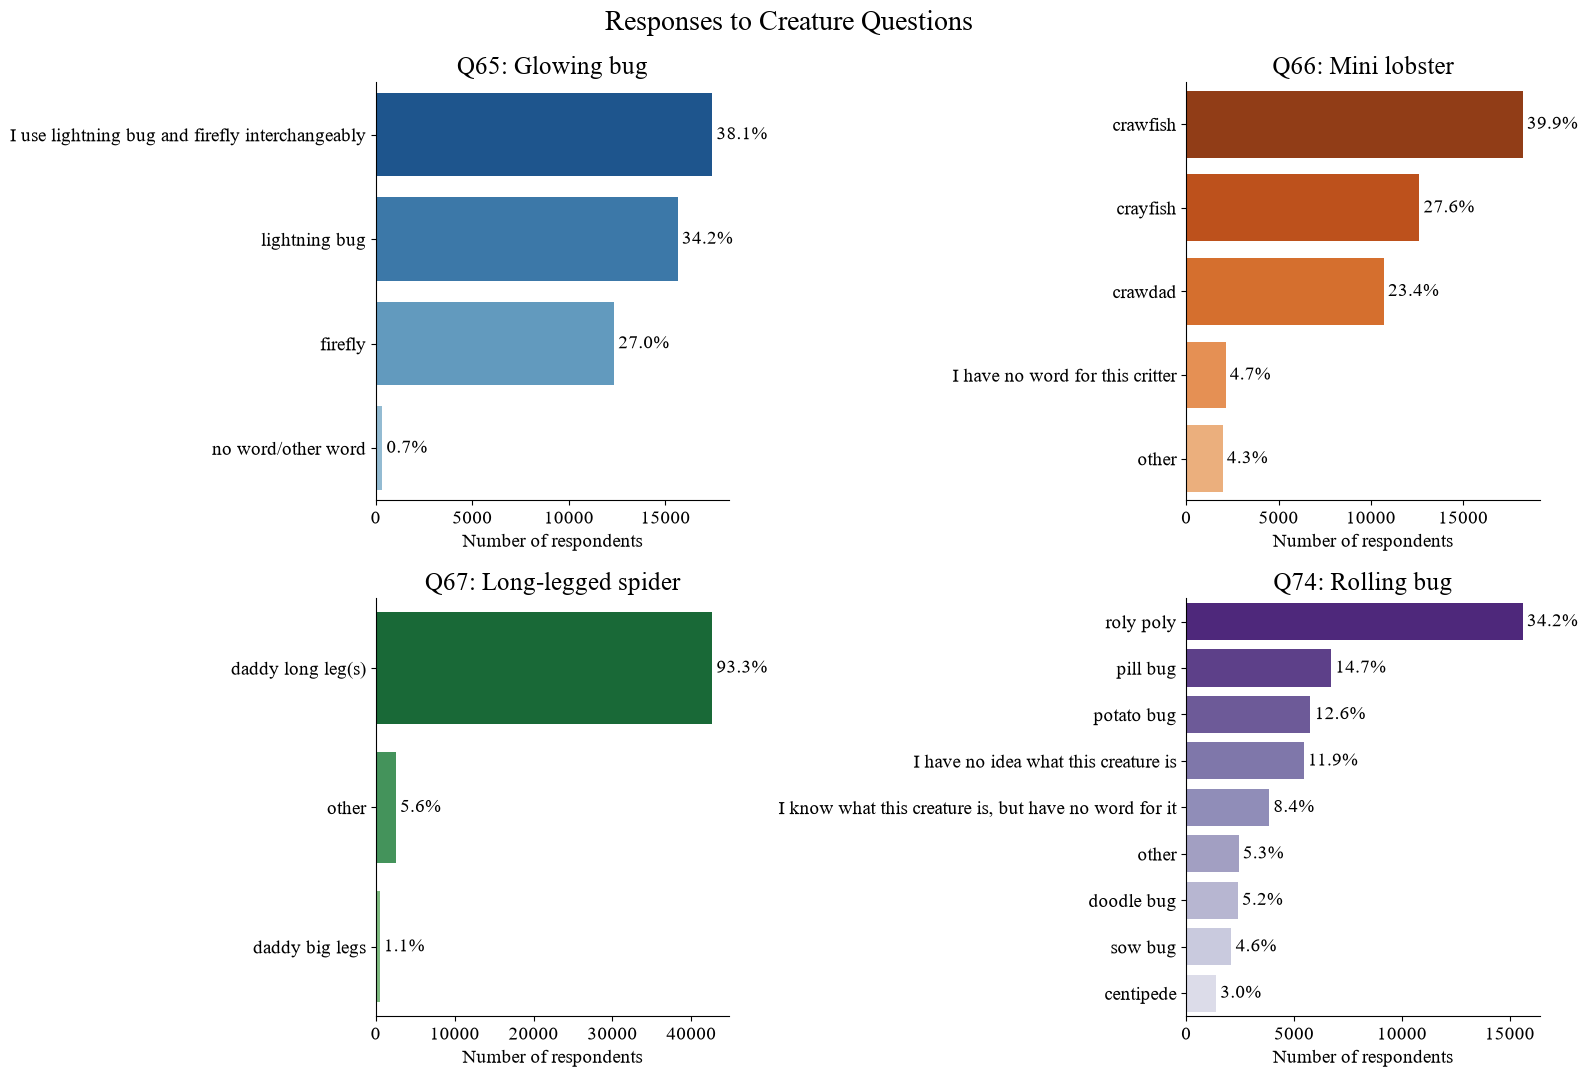

In [199]:
# 1. Select the exact 4 creature columns
creature_cols = ["Q065_grouped", "Q066_grouped", "Q067_grouped", "Q074_grouped"]

titles = ["Q65: Glowing bug", "Q66: Mini lobster",
          "Q67: Long-legged spider", "Q74: Rolling bug"]

palettes = ["Blues", "Oranges", "Greens", "Purples"]   # one color family per question

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

for ax, col, title, pal in zip(axes.flatten(), creature_cols, titles, palettes):
    counts = ling_data_creatures[col].value_counts()

    # Darkest shade for the most common answer; skip the palest shades so bars stay visible
    colors = sns.color_palette(pal, len(counts) + 2)[2:][::-1]

    sns.countplot(data=ling_data_creatures, y=col, order=counts.index,
                  hue=col, hue_order=counts.index, palette=colors,
                  legend=False, ax=ax)

    # Label each bar with its percentage of respondents who answered
    pct = (counts / counts.sum() * 100).round(1)
    for container, p in zip(ax.containers, pct):
        ax.bar_label(container, labels=[f"{p}%"], padding=3, fontsize=14)

    ax.set_title(title, fontsize=18)
    ax.set_xlabel("Number of respondents")
    ax.set_ylabel("")
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle("Responses to Creature Questions", fontsize=20)
plt.tight_layout()
plt.show()

When looking at more questions, it is interesting to note that some responses, such as for the long-legged spider, do not have much variation. That is, there is a clear word that most people use to describe this creature. In other cases, there are a few words that stand out about equally and a smaller portion of the population does not have or has another word for the creature that was not available on the survey. Interestingly, in the case of the rolling bug, multiple respondants had different words for the bug. Also curious is that many respondants did not know what this creature was. This could be due to the way the question was written or possibly geographic natural habitat range of this animal means that some individuals are less likely to encounter them.
<br>
This is important to note for the rest of the rest of the report, since we can note that some groups will have little variance and contribute less to any PCA analysis. Further, some responses such as "I have no idea what this creature is," as seen in question 74, could cause problems, especially since lack of knowledge is not something that we are trying to analyze. If two people from very separate regions claim they do not know what they call a certain creature, then clustering models may draw a false geographic equivalency between them. Lastly, there is variation in the number of dimensions for each question. Question 74 about the rolling bugs has multiple responses that increases the dimentionality and can potentially impact a future model. Questions like this will have to be noted when reducing dimensions.

# Dimension Reduction

-   This is where you discuss and show plots about the results of
    whatever dimension reduction techniques you tried---PCA, variants of
    PCA, t-SNE, NMF, random projections, etc.

-   What do you learn from your dimension reduction outputs

-   Discuss centering and scaling decisions

In [200]:
# One-hot encoding so that the response is binary instead of categorical
# ling_location has this, but I will recreate it since ling_location was not cleaned

qu_columns = ling_data_final.filter(regex=r'^Q\d+$').columns
print("Questions: ", len(qu_columns)) #67 columns after taking away first 50 and others

# Mark non-answers (0) as missing, so they don't become their own answer column
answers_zero_as_na = ling_data_final[qu_columns].mask(lambda d: d.eq(0))

# One-hot encode: one 0/1 column per answer, named like 'Q065_2'
onehot = pd.get_dummies(answers_zero_as_na.astype('category'), prefix_sep='_', dtype=int)

print("Zeros (no answer):", (ling_data_final[qu_columns] == 0).sum().sum())
print("Existing NaNs:", ling_data_final[qu_columns].isna().sum().sum())

print("Respondents:", onehot.shape[0], "| answer columns:", onehot.shape[1])
onehot.head()


Questions:  67
Zeros (no answer): 30984
Existing NaNs: 0
Respondents: 46018 | answer columns: 468


,Q050_1.0,Q050_2.0,Q050_3.0,Q050_4.0,Q050_5.0,Q050_6.0,Q050_7.0,Q050_8.0,Q050_9.0,Q051_1.0,...,Q120_4.0,Q120_5.0,Q120_6.0,Q121_1.0,Q121_2.0,Q121_3.0,Q121_4.0,Q121_5.0,Q121_6.0,Q121_7.0
0,0,0,0,1,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
1,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,0,0,0,1,0,0,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0
3,0,0,0,0,0,0,1,0,0,1,...,0,0,0,1,0,0,0,0,0,0
4,0,0,0,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,0,0


Centered Matrix Shape: (46018, 468)


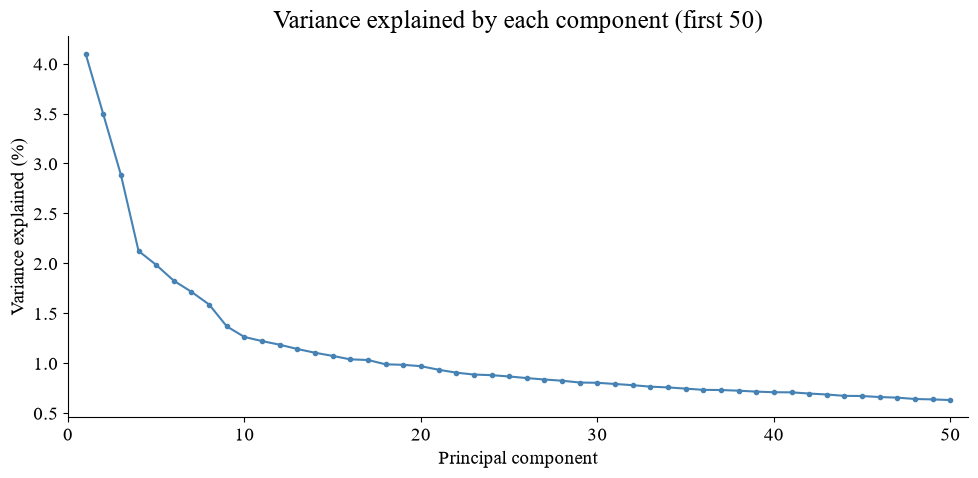

42 components explain at least 50% of the variance
78 components explain at least 70% of the variance
107 components explain at least 80% of the variance
156 components explain at least 90% of the variance

K=10 captures the major structural variance.


In [201]:
# Now we will try PCA
# We will be centering since a "0" does not have contextual meaning

# Mean-centering 
X_centered = onehot - onehot.mean(axis=0)

print("Centered Matrix Shape:", X_centered.shape)


pca = PCA()
pc_scores = pca.fit_transform(X_centered)

explained = pca.explained_variance_ratio_ * 100
cumulative = explained.cumsum()
components = range(1, len(explained) + 1)

# Scree plot to use Elbow method
# This will find a good K for us to use
# K is the chosen number of reduced dimensions
thresholds = [50, 70, 80, 90]
needed = {t: int((cumulative >= t).argmax() + 1) for t in thresholds}

# Plot Elbow
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(components[:50], explained[:50], color='steelblue', marker='o', markersize=3, linewidth=1.5)
ax1.set_xlim(0, 51)  # Zoom in on PCs 1 through 50
ax1.set_xlabel("Principal component")
ax1.set_ylabel("Variance explained (%)")
ax1.set_title("Variance explained by each component (first 50)", fontsize=18)
ax1.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

# Threshold summary loop
for t in thresholds:
    print(f"{needed[t]} components explain at least {t}% of the variance")

print("\nK=10 captures the major structural variance.")



First 10 components explain 22.3% of the variance


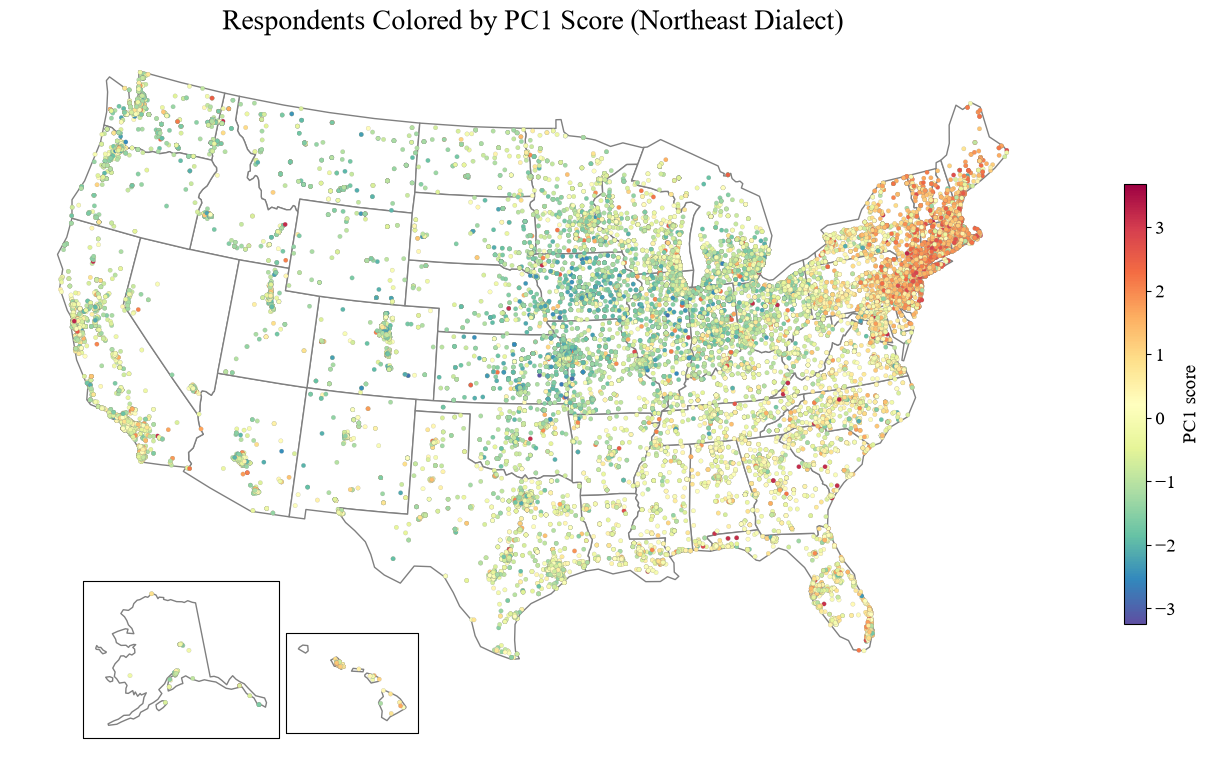

In [202]:
n_pcs = 10    # from the elbow in the scree plot

scores = pd.DataFrame(pc_scores[:, :n_pcs], index=onehot.index,
                      columns=[f"PC{i+1}" for i in range(n_pcs)])

print(f"First {n_pcs} components explain {cumulative[n_pcs-1]:.1f}% of the variance")
scores.head()

pts_m['PC1'] = scores['PC1'].reindex(pts_m.index)

fig, ax = plt.subplots(figsize=(14, 8))
states_m.plot(ax=ax, color='white', edgecolor='grey', linewidth=1)
boxes_m.boundary.plot(ax=ax, color='black', linewidth=0.8)
pts_m.dropna(subset=['PC1']).plot(ax=ax, column='PC1', cmap='Spectral_r',
                                  markersize=10, edgecolor='grey', linewidth=0.1,
                                  legend=True, zorder=3,
                                  legend_kwds={'shrink': 0.6, 'label': 'PC1 score'})
ax.set_title("Respondents Colored by PC1 Score (Northeast Dialect)", fontsize=20)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [203]:
loadings = pd.DataFrame(
    pca.components_[:10, :].T,  # Transpose top 10 components!
    index=onehot.columns,
    columns=[f"PC{i+1}" for i in range(10)]
)

# View top drivers for PC1 
pc = 'PC1'
print(f"=== TOP ANSWERS DRIVING {pc} ===")
print("\nMost Positive (High Score Drivers):")
print(loadings[pc].nlargest(10))

=== TOP ANSWERS DRIVING PC1 ===

Most Positive (High Score Drivers):
Q073_1.0    0.266116
Q105_1.0    0.195577
Q080_1.0    0.184148
Q056_2.0    0.157910
Q078_2.0    0.143250
Q095_1.0    0.141467
Q103_4.0    0.136716
Q086_1.0    0.135290
Q119_1.0    0.128752
Q099_2.0    0.112243
Name: PC1, dtype: float64


In [204]:
# Q73 -> Gym shoes term
# Q105 -> Generic term for carbonated beverage
# Q80 -> Rain fall with sun
# Q56 -> Pantyhose suntan
# Q78 -> Used paper
# Q95 -> "the City"
# Q103 -> Thing for water in school
# Q86 -> Use of 'cruller'
# Q119 -> Food you take from restaurant
# Q 99 -> Road parallel to highway

In [205]:
# Now I am going to use t-SNE
# This should highlight the local relationships

#From the US Census Bueau's four regions: https://www2.census.gov/geo/pdfs/maps-data/maps/reference/us_regdiv.pdf
census_region = {
    **dict.fromkeys(['CT', 'ME', 'MA', 'NH', 'RI', 'VT', 'NJ', 'NY', 'PA'], 'Northeast'),
    **dict.fromkeys(['IL', 'IN', 'MI', 'OH', 'WI', 'IA', 'KS', 'MN', 'MO', 'NE', 'ND', 'SD'], 'Midwest'),
    **dict.fromkeys(['DE', 'DC', 'FL', 'GA', 'MD', 'NC', 'SC', 'VA', 'WV', 'AL', 'KY', 'MS',
                     'TN', 'AR', 'LA', 'OK', 'TX'], 'South'),
    **dict.fromkeys(['AZ', 'CO', 'ID', 'MT', 'NV', 'NM', 'UT', 'WY', 'AK', 'CA', 'HI',
                     'OR', 'WA'], 'West'),
}

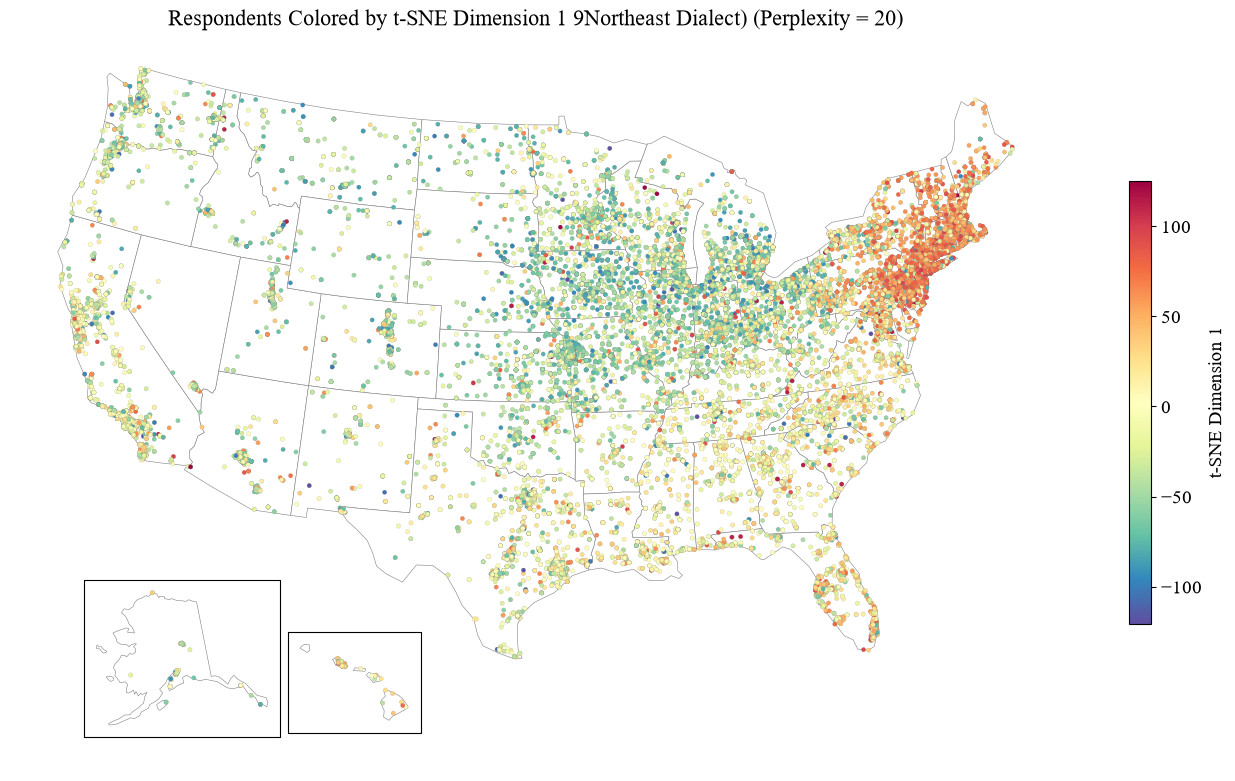

In [206]:
# Map: each sampled respondent at their real location, colored by t-SNE position

perplexity = 20
tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42, n_jobs=-1)

# Run t-SNE using the top 10 components from pc_scores
tsne_results = tsne.fit_transform(pc_scores[:, :10])

# Matching onehot indices
embedding = pd.DataFrame(
    tsne_results, 
    columns=['TSNE1', 'TSNE2'], 
    index=onehot.index
)

# 3. Scale each t-SNE axis to 0-1 (optional, for normalized comparison)
t01 = (embedding - embedding.min()) / (embedding.max() - embedding.min())

# 4. Attach t-SNE coordinates to your spatial map points
sample_pts = pts_m.loc[pts_m.index.intersection(embedding.index)].copy()
sample_pts['TSNE1'] = embedding.loc[sample_pts.index, 'TSNE1']

# 5. Plot geographic map colored by t-SNE Dimension 1
fig, ax = plt.subplots(figsize=(14, 8))
states_m.plot(ax=ax, color='white', edgecolor='grey', linewidth=0.4)
boxes_m.boundary.plot(ax=ax, color='black', linewidth=0.8)

sample_pts.plot(
    ax=ax, column='TSNE1', 
    cmap='Spectral_r', 
    markersize=10, edgecolor='grey', linewidth=0.1,
    legend=True, 
    zorder=3,
    legend_kwds={'shrink': 0.6, 'label': 't-SNE Dimension 1'}
)

ax.set_title(f"Respondents Colored by t-SNE Dimension 1 9Northeast Dialect) (Perplexity = {perplexity})", fontsize=16)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In this section, we did center the data so that we could detect any differences in language from the "average" choices. This way, local trends could seem more distinctive. We decided not to scale so that every answer could have equal importance. Standardizing binary variables inversely weights features by frequency, which can amplify rare choices ("Other" or "Don't know") into huge spikes. There was no need to weight any of the answers more heavily. <br>

The original lingData dataset had response codes, but these are quite arbitrary and ordinal. These codes had 1 for 'a', 2 for 'b', 3 for 'c', etc. Running PCA directly on raw integers falsely assumes an ordinal metric space where choice 5 is mathematically "greater than" choice 3 or 4.  However, that is not the case, and they are all have the same "value" in context. We used one-hot encoding to ensure that each answer was given its own dimensional space, allowing us to look across all answers for trends in shared responses.<br>

Linear PCA cleanly isolates the primary national variance on PC1, pointing directly to a distinct Northeastern/Mid-Atlantic dialect. For this analysis, we determined the optimal number of dimensions (K) for both the PCA and t-SNE projections. We used a scree plot to see the variance per principle components. There was a clear elbow and flattening at K=10. Therefore, we know that most of the variance is captured with 10 principle components.

However, to more clearly define language areas, and better evaluate non-linear language clusters, we also projected the data using t-SNE on the top 10 PCs. Both PCA and t-SNE produce similar trends, but the t-SNE shows more distinct clusters. Since the t-SNE has a greater focus on local attributes, we can better identify differences in dialect choices. For our graph, we used a perplexity score of 20, which captures a bit more detail. It as opposed to PCS, the t-SNE more clearly separates the north eastern states, Rust Belt states, and even gives some distinction to the the south east, confirming that there are real regional patterns.



# Clustering

-   This is where you discuss and show plots about the results of
    whatever clustering methods you tried---k-means, hierarchical
    clustering, NMF, etc.

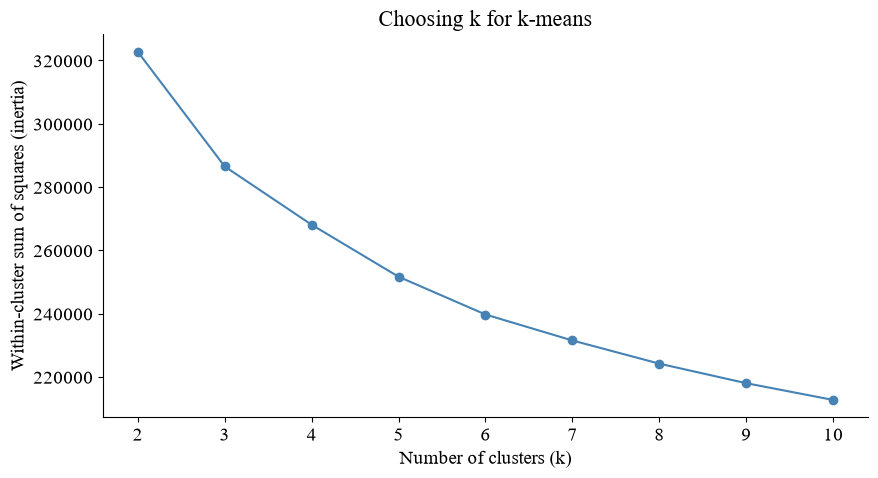

k = 3: silhouette = 0.142
k = 4: silhouette = 0.126
k = 5: silhouette = 0.141
k = 6: silhouette = 0.134
k = 7: silhouette = 0.127
k = 8: silhouette = 0.112


In [207]:
# Begin with k-means clustering, first look for a good K to use!
# Use an elbow plot and a shillouette score

k_values = range(2, 11)
inertias = []

for k in k_values:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(scores)
    inertias.append(km.inertia_)

# --- 2. Elbow plot ---
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(k_values), inertias, marker='o', color='steelblue')
ax.set_xticks(list(k_values))
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Within-cluster sum of squares (inertia)")
ax.set_title("Choosing k for k-means", fontsize=16)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

sample_idx = scores.sample(5_000, random_state=42).index

for k in range(3, 9):
    labels = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(scores)
    labels = pd.Series(labels, index=scores.index)
    s = silhouette_score(scores.loc[sample_idx], labels.loc[sample_idx])
    print(f"k = {k}: silhouette = {s:.3f}")

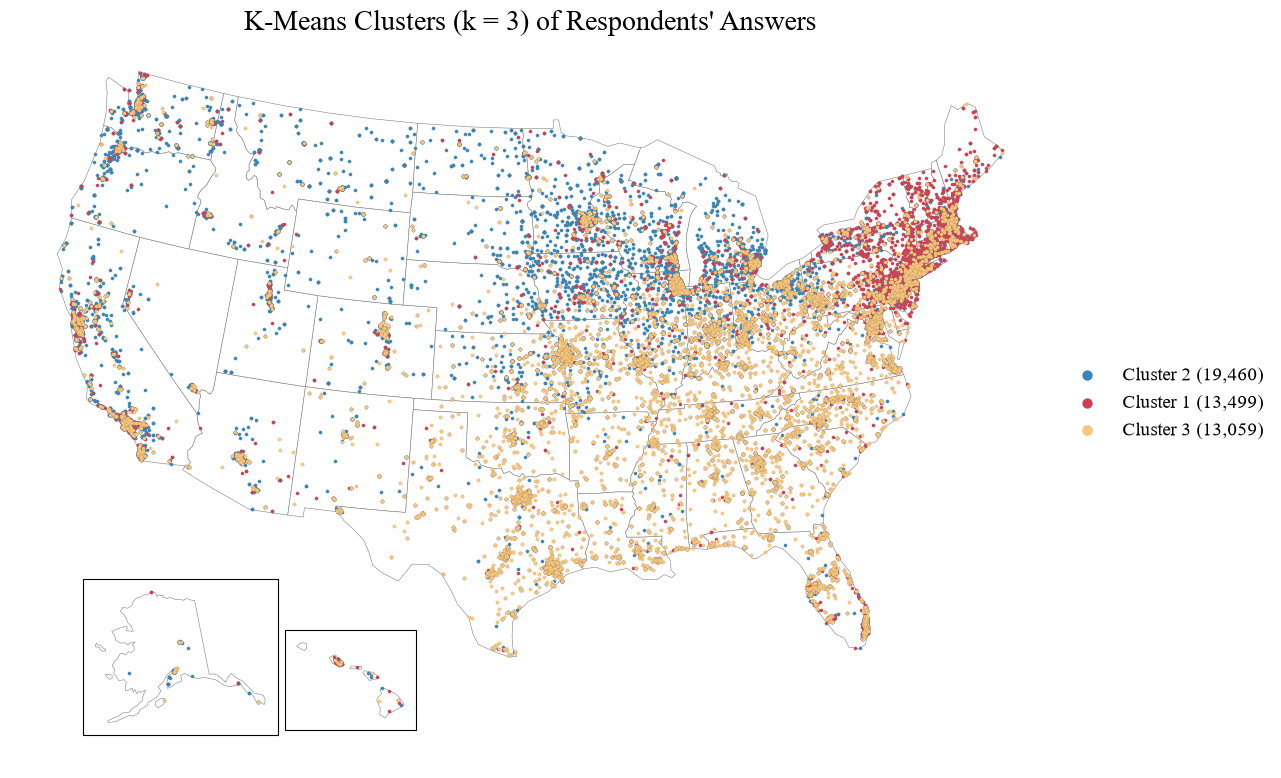

cluster
0    1.51
1   -0.85
2   -0.30
Name: PC1, dtype: float64


In [208]:
# Based on elbow and silhouette score, chosing k=3.

k = 3
kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
clusters = pd.Series(kmeans.fit_predict(scores), index=scores.index, name='cluster')
pts_m['cluster'] = clusters.reindex(pts_m.index)

# Order clusters by average PC1 score (low → high), and give them colors from
# the same Spectral_r colormap: blue → yellow-orange → red
pc1_order = scores['PC1'].groupby(clusters).mean().sort_values().index
spectral = plt.get_cmap('Spectral_r')
cluster_colors = dict(zip(pc1_order, [spectral(0.1), spectral(0.65), spectral(0.9)]))

fig, ax = plt.subplots(figsize=(14, 8))
states_m.plot(ax=ax, color='white', edgecolor='grey', linewidth=0.4)
boxes_m.boundary.plot(ax=ax, color='black', linewidth=0.8)

# Draw largest clusters first, so smaller ones end up on top
sizes = pts_m['cluster'].value_counts()
for layer, c in enumerate(sizes.index):
    pts = pts_m[pts_m['cluster'] == c]
    pts.plot(ax=ax, color=cluster_colors[c], markersize=6,
             edgecolor = 'grey', linewidth=0.1, zorder=3 + layer,
             label=f"Cluster {int(c) + 1} ({len(pts):,})")

ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), markerscale=3, frameon=False)
ax.set_title(f"K-Means Clusters (k = {k}) of Respondents' Answers", fontsize=20)
ax.set_axis_off()
plt.tight_layout()
plt.show()

print(scores['PC1'].groupby(clusters).mean().round(2))

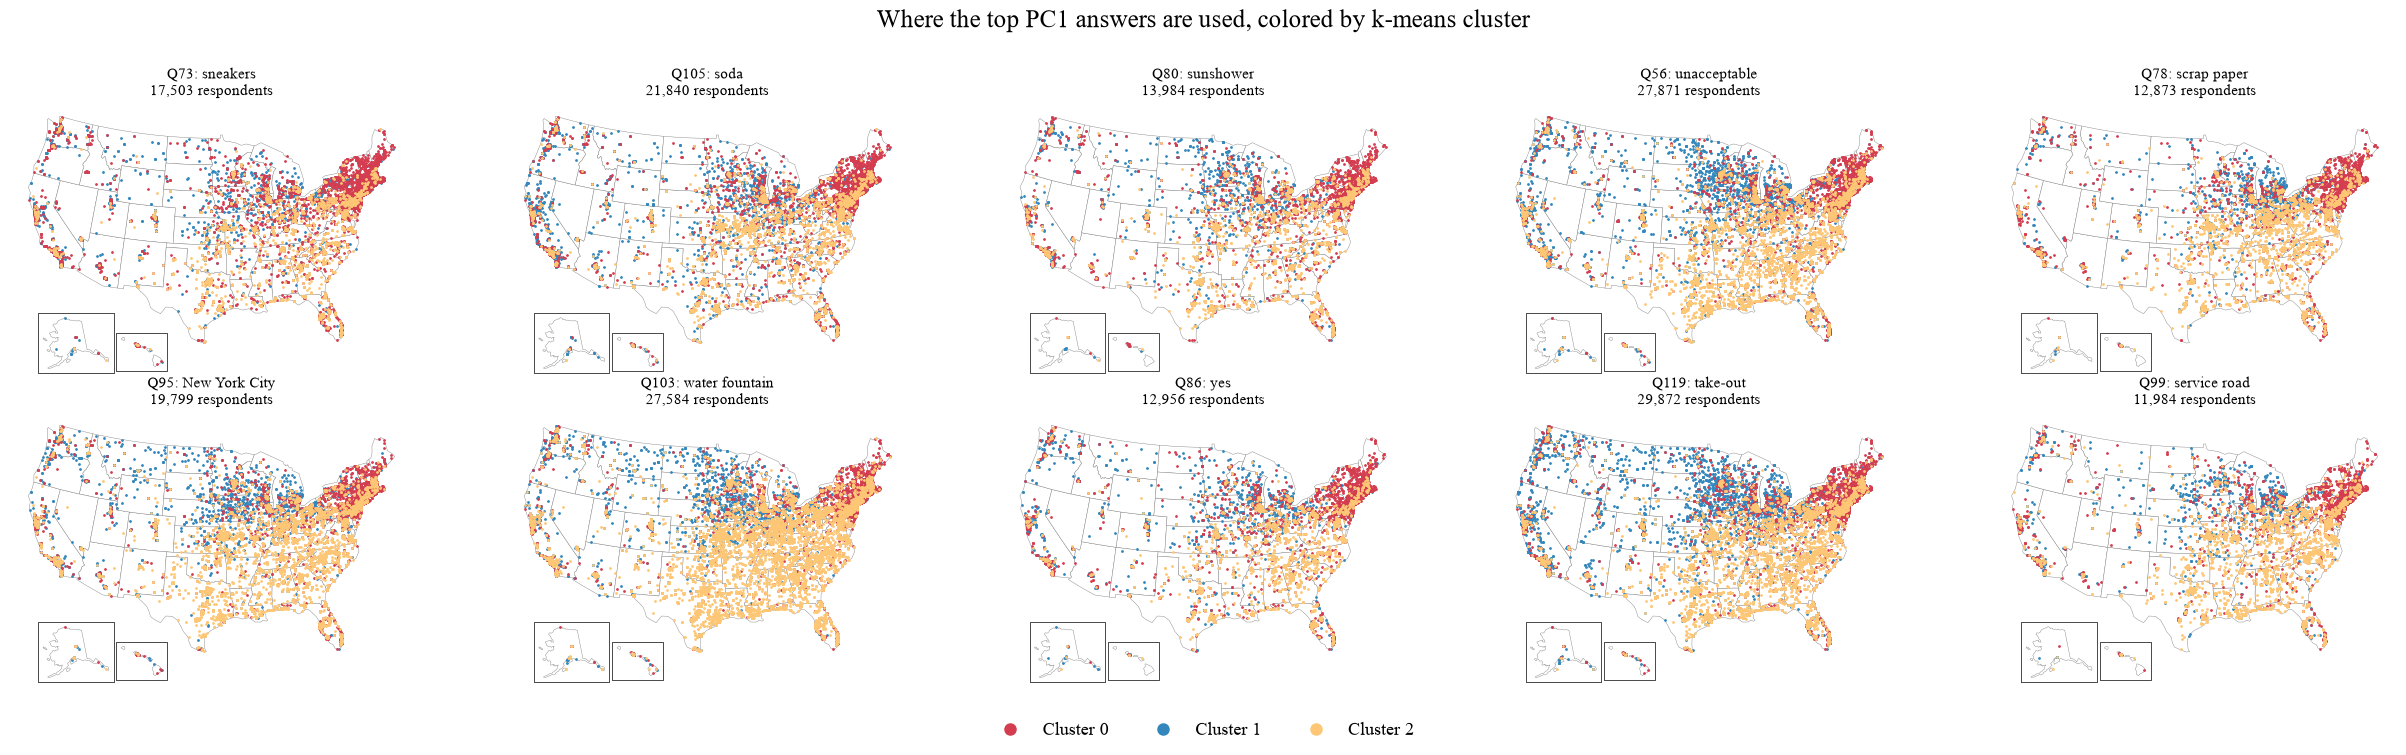

In [209]:
# Looking at each principle component map separately, 
# see if any form the most distinct clusters

n_cols = 5
n_rows = math.ceil(len(top_pc1) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.8 * n_rows))

# Draw largest clusters first, so smaller ones end up on top
cluster_order = pts_m['cluster'].value_counts().index

for ax, col in zip(axes.flatten(), top_pc1):
    chose = onehot.index[onehot[col] == 1]                  # respondents who gave this answer
    pts = pts_m.loc[pts_m.index.intersection(chose)]

    states_m.plot(ax=ax, color='white', edgecolor='grey', linewidth=0.3)
    boxes_m.boundary.plot(ax=ax, color='black', linewidth=0.5)

    for layer, c in enumerate(cluster_order):
        pts[pts['cluster'] == c].plot(ax=ax, color=cluster_colors[c], markersize=1,
                                      zorder=3 + layer)

    ax.set_title(f"{textwrap.fill(answer_text(col), 32)}\n{len(pts):,} respondents", fontsize=11)
    ax.set_axis_off()

# Hide any empty panels
for ax in axes.flatten()[len(top_pc1):]:
    ax.set_visible(False)

# One shared legend for the clusters
handles = [Line2D([0], [0], marker='o', linestyle='', markersize=8,
                  color=cluster_colors[c], label=f"Cluster {c}")
           for c in sorted(cluster_colors)]
fig.legend(handles=handles, loc='lower center', ncol=len(handles), frameon=False, fontsize=13)

fig.suptitle("Where the top PC1 answers are used, colored by k-means cluster", fontsize=18)
plt.tight_layout(rect=(0, 0.05, 1, 0.97))
plt.show()

Heriarchical Clustering


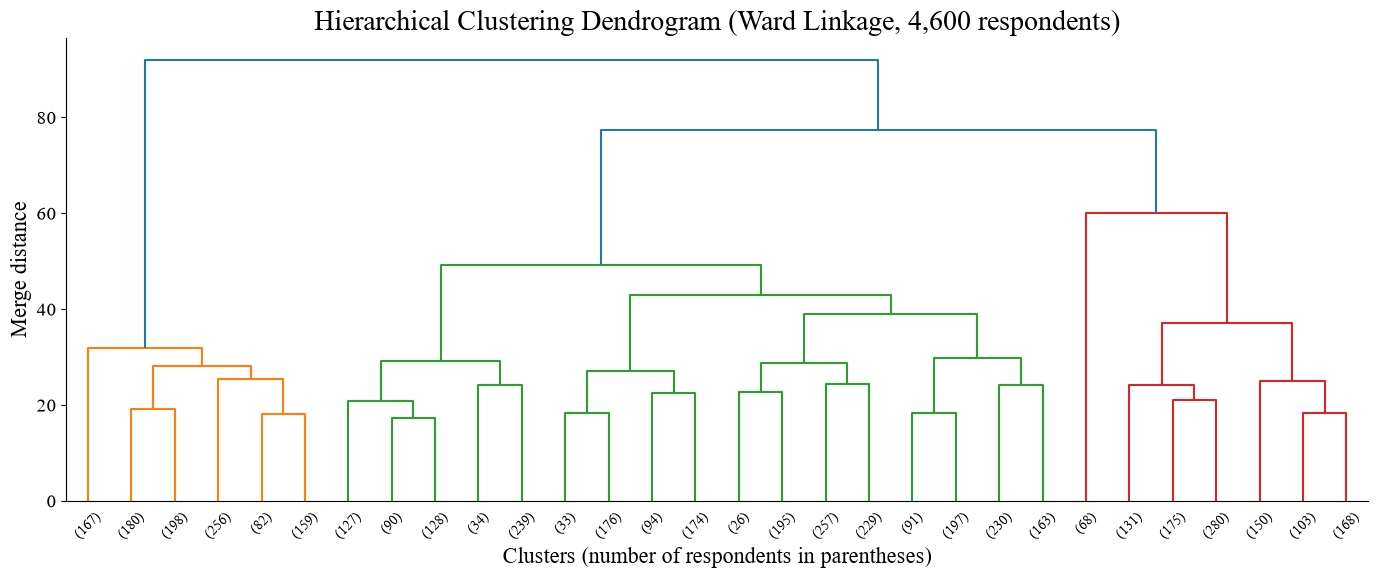

In [210]:
# Hierarchical clustering on a sample, using the 10 PCA scores
hc_sample = scores.sample(4600, random_state=42) # Sample 10% of data
Z = linkage(hc_sample, method='ward')

# --- 2. Dendrogram (top of the tree only) ---
fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, truncate_mode='lastp', p=30, show_leaf_counts=True,
           color_threshold=None, ax=ax)
ax.set_title("Hierarchical Clustering Dendrogram (Ward Linkage, 4,600 respondents)", fontsize=20)
ax.set_xlabel("Clusters (number of respondents in parentheses)", fontsize=16)
ax.set_ylabel("Merge distance", fontsize=16)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

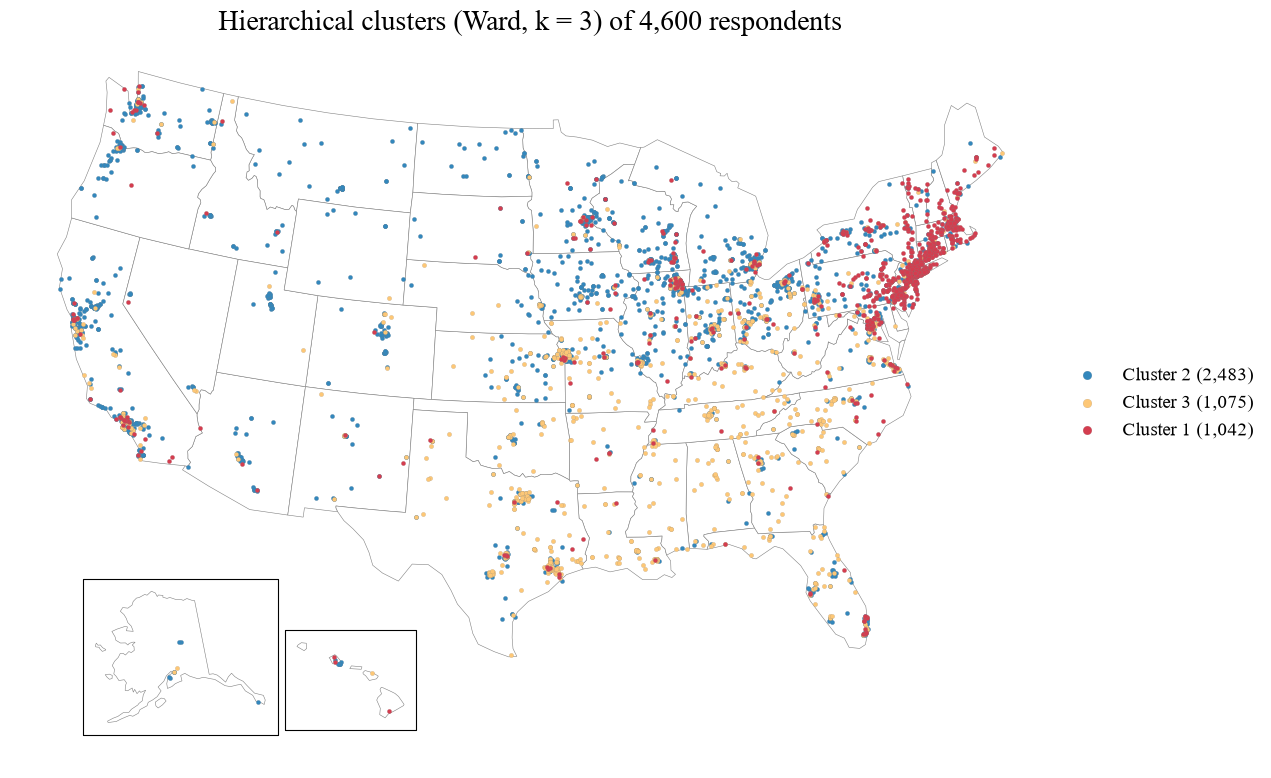

In [211]:
# Cut the tree into 3 clusters with confirmed k value of 3
hc_k = 3
hc_labels = pd.Series(fcluster(Z, t=hc_k, criterion='maxclust'), index=hc_sample.index)

# Color by average PC1 score, matching the k-means map
pc1_order = scores.loc[hc_sample.index, 'PC1'].groupby(hc_labels).mean().sort_values().index
spectral = plt.get_cmap('Spectral_r')
hc_colors = dict(zip(pc1_order, [spectral(0.1), spectral(0.65), spectral(0.9)]))

hc_pts = pts_m.loc[pts_m.index.intersection(hc_sample.index)].copy()
hc_pts['hc_cluster'] = hc_labels.loc[hc_pts.index]

fig, ax = plt.subplots(figsize=(14, 8))
states_m.plot(ax=ax, color='white', edgecolor='grey', linewidth=0.4)
boxes_m.boundary.plot(ax=ax, color='black', linewidth=0.8)

sizes = hc_pts['hc_cluster'].value_counts()
for layer, c in enumerate(sizes.index): # largest first, smallest on top so we can see
    pts = hc_pts[hc_pts['hc_cluster'] == c]
    pts.plot(ax=ax, color=hc_colors[c], markersize=10,
             edgecolor='grey', linewidth=0.1, zorder=3 + layer,
             label=f"Cluster {c} ({len(pts):,})")

ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), markerscale=2, frameon=False)
ax.set_title(f"Hierarchical clusters (Ward, k = {hc_k}) of 4,600 respondents", fontsize=20)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [212]:
# k-means labels for the same 4,600 respondents used in hierarchical clustering
km_sample = clusters.loc[hc_sample.index]

ari_km_hc = adjusted_rand_score(km_sample, hc_labels) # frpm scikit library
print(f"Adjusted Rand index (k-means vs. hierarchical): {ari_km_hc:.3f}")

# How respondents in each hierarchical cluster were assigned by k-means
ct_pct = pd.crosstab(hc_labels, km_sample, rownames=['Hierarchical'], colnames=['k-means'],
                     normalize='index').mul(100).round(1)
display(ct_pct)

Adjusted Rand index (k-means vs. hierarchical): 0.502


k-means,0,1,2
Hierarchical,,,
1,95.7,1.4,2.9
2,11.3,74.1,14.6
3,7.6,9.7,82.7


We selected k = 3 to produce interpretable and stable regional boundaries. To select this value, we first explored which k to use with the elbow method. However, the elbow graph did not have a distinctive curve, so we then looked at the silhouette scores for a few k values. We took the k value with the highest silhouette score, k = 3. This cleanly isolated the Northeast corridor, the Southeast, and a broad General American baseline, which directly matches the patterns identified in our PCA and t-SNE projections. <br>

In the k-means clustering graph, we found that there were not completely separate clusters. There was generally a continuum, with distinct regional groups. Urban centers seemed to have tight core clusters, while rural areas and transitional zones blended across boundaries. When looking at individual components, we can see that none of even our top principle components form completely distinct geographic groups from each other. There is always a little bit of overlap. While even the best prinipal components contribute to the continuum, we would imagine that the smallest principle components would contribute most to it. Questions about the term for gym shoes (question 73) and name of a carbonated beverage (quesiton 105) where the two most likley to make distinctive clusters.  <br>

K-means was a good method to use because it was able to handle all of the data and fit its centroid-based groupings over the principle component space. However, because of its rigid, circular boundaries, there are cutoffs that may not make as much sense when considering a continuous linguistic landscape. It also required us to choose k up front, which added an extra step and added uncertainty. We then moved on to the heirarchical clustering method. This method allows us to ease the constraints of the k-means strict circular boundaries and use a tree-like structure to find connections within and between communities. Using the dendrogram, we could visually inspect the best k to use, so that we did not have to add arbitrary human decision into the pipeline.  We used the Ward method becuase it minimizes the variance within clusters, allowing for more tight clusters to be seen and becuase is more robust to outliers. In this case, our dendrogram confirmed our k from the k-means clustering, affirming that there are generally three main dialectic groupings. However, hierarchical clustering is more complex, so we had to take only 10 percent of the responses due to its computational complexity.

When comparing the two clustering methods with the Adjusted Rand Index, we see that they have a moderately strong agreement. The adjusted rand score was 0.502, meaning that the results from the k-means and hierarchical clustering yielded clusters that mapped quite well to each other. When looking at the crosstab matrix, we can see that for the first cluster, the assignments made by each model agree over 95% of the time. This first cluster denotes the northeastern dialect, so this illustrates that both models generally agree on what locations have the northeastern dialect. There are also strong correspondences between the second and third clusters (midwest/Rust Belt and southeast regions, respectively) at 74.1% and 82.7% compatibility across these groups.


# Stability of findings to perturbation

-   What happens to your clusters when you perturb the data set?

-   What happens when you re-run the algorithm with different starting
    points?

,Runs,Mean ARI,Min ARI,Max ARI
Different starting points,20,0.977,0.934,0.996


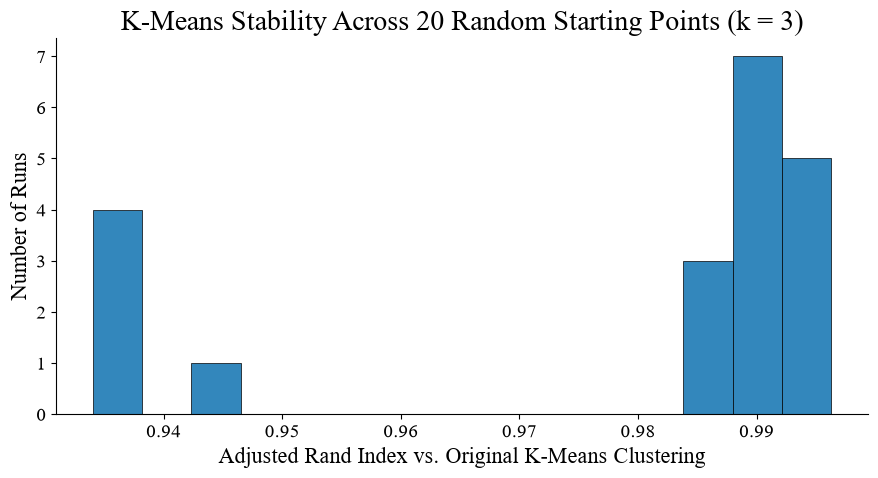

In [213]:
k = 3
reference = clusters.loc[scores.index]

# Rerun k-means from 20 different starting points (one start each); different random seeds
seeds = range(20)
seed_ari = pd.Series(
    [adjusted_rand_score(reference,
                         KMeans(n_clusters=k, n_init=1, random_state=s).fit_predict(scores))
     for s in seeds],
    index=seeds, name='ARI')

seed_summary = pd.DataFrame({
    'Runs': [len(seed_ari)],
    'Mean ARI': [seed_ari.mean()],
    'Min ARI': [seed_ari.min()],
    'Max ARI': [seed_ari.max()],
}, index=['Different starting points'])

display(seed_summary.style.format({'Mean ARI': '{:.3f}', 'Min ARI': '{:.3f}', 'Max ARI': '{:.3f}'}))

# --- Histogram of ARI across starting points ---
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(seed_ari, bins=15, color=plt.get_cmap('Spectral_r')(0.1),
        edgecolor='black', linewidth=0.5)
ax.set_xlabel("Adjusted Rand Index vs. Original K-Means Clustering", fontsize = 16)
ax.set_ylabel("Number of Runs", fontsize = 16)
ax.set_title(f"K-Means Stability Across 20 Random Starting Points (k = {k})", fontsize=20)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [214]:
# For hierarchical, choose a different random sample of 4600 each time
# Bootstrapping!

hc_k = 3
hc_ari = []

for s in range(20):
    # New random sample of 4600 respondents, clustered with Ward
    samp = scores.sample(4600, random_state=s)
    labels = fcluster(linkage(samp, method='ward'), t=hc_k, criterion='maxclust')

    # Center of each new cluster in PCA space
    centers = samp.groupby(labels).mean()

    #Label each original 
    assigned = pairwise_distances_argmin(hc_sample, centers)
    hc_ari.append(adjusted_rand_score(hc_labels, assigned))

hc_ari = pd.Series(hc_ari, name='ARI')

# Making table for
hc_summary = pd.DataFrame({
    'Runs': [len(hc_ari)],
    'Mean ARI': [hc_ari.mean()],
    'Min ARI': [hc_ari.min()],
    'Max ARI': [hc_ari.max()],
}, index=['Hierarchical: different random samples'])


seed_summary.index = ['K-means: different starting points']
stability = pd.concat([seed_summary, hc_summary])

display(stability.style.format({'Mean ARI': '{:.3f}', 'Min ARI': '{:.3f}', 'Max ARI': '{:.3f}'}))

,Runs,Mean ARI,Min ARI,Max ARI
K-means: different starting points,20,0.977,0.934,0.996
Hierarchical: different random samples,20,0.522,0.424,0.614


K-means chooses the centroids of its starting points at random, so we tested the sensitivity of different initial starting points by assigning 20 new random seeds, running the k-means model, and then using the Adjusted Rand Index to determine how similar each run was to our first mapped run performed earlier in the report. We can see that there is a little bit of a difference in some of the trials, however, the clusters found by these k-means trials were generally quite similar to our original k-means run.
<br>
Then, for our hierarchical clustering, we bootstrapped the sample 20 times and then compared each bootstrapped run to the original hierarchical clustering we performed earlier. Bootstrapping essentially chooses a new set of 4600 sample points with replacement. We can see that this model still remains relatively stable, however there are greater differences between the bootstrapped runs and the original hierarchical clustering than there was difference between the k-means. This indicates a bit less stability for this model. Even if it was able to give us more refined geographic areas for our clusters, they are not necessarily as reliable as the k-means runs.
<br>
In summary, the stability analysis confirmed that while hierarchical clustering provided more distinctive insights into the dialect distributions in the US, k-means serves as a more robust method, since it is more stable and reliable when perturbed.

# Conclusion


The three realms of data science, the data realm, algorithms and analysis realm, and future data realm, are all relevant to the analysis done in this report. Firstly, the survey data used in this report provides a foundational understanding of how different regions have different communication and language trends across the US. It is important to note that this data was all self-reported and the users understanding of the question likely played a large roll in how they answered. Further, language can evolve over time and as people move cities, they can bring with them the dialect of their hometowns. Other factors such as place of birth, parents place of birth, social media trends, and location population density may all play a roll in these dialectical differences. The data we have is extremely helpful to create a baseline, but it can by no means give an exhaustive exploration of language differences by region. 
<br>
The algorithms and analysis used in this study consistently showed three large clusters of dialect: the northeast, the midwest, and the general amercian baseline with distinct presence in the southeast. These algorithms can be used in conjunction with this data to add inclusivity and equity in political platforms or marketing schemes. For example, a commerical for a bubbly soda may use different language or a political message may contain different keywords based on the three main regions their campaign falls in. The algorithms seem like an effective way to test lexical trends over a large geographic area like the US.
<br>
Lastly, the future data realm. Because of the stability shown by our clustering models, we can conclude that any new participant of the survey is likely to fall into one of the three main clusters found. While we can clearly see that the questions in this survey revealed lexial differences from 2006, it would be interesting to know if the trends found still apply, or if it is weaker now that there have been 20 years for humans to mix, migrate, and connect over the internet. We would hesistate to say anything concretely unless another study was performed. 
<br>
A reality check to verify the clustering could be to map from the hometowns of these individuals rather than their current locations. Although that data is not available, it may help control for any migration that occurs. In 2006, there were fewer online news sources, but perhaps looking at language used in paper news publications could also help verify some of the results of this analysis.
<br>
The main takeaways of this analysis is that there are three distinct dialectics in the US: northeast, midwest/Rust Belt, and the general american dialect distributed throughout the south east and found largely in urban cities. Dimensionality reduction and k-means provides a robust way to visualize where dialectical differences occur throughout the US geography. Heirarchical clustering offers nice detail, but tends to have greater variance under bootstrapping. If there were more time, we would have done some manual imput for the data cleaning, especially if some geographic points were known but needed input by hand. We also would explore other clustering methods like NMF (Non-Negative Matrix Factorization), since survey results are non-negative and this method is routinely used in text mining. 



# Academic Honesty {#academic-integrity-statement}

## Statement

Professor Bin, <br><br>
For these assignments, I will maintain academic integrity and cite all sources that are used including collaborations and LLM use. <br>
Academic research honesty is necessary for the ultimate trustworthiness of future scientific knowledge. Being open about assumptions made and how conclusions were drawn can ensure that generalizations are minimized and the statistics can stay as objective as possible. In a world where it can be easy to skew the statistics to support a particular point of view, research performed with integrity can help minimize the misinterpretation of the data. Further, if science was made to understand life's complexities, then it is imperative that assumptions be observed, listed and challenged. Then, we can have a more robust foundation to build future research that can withstand the test of time. We can celebrate inquiry, notice where we fail, and not let that deter us from the pursuit of something a bit greater. Being honest about research means renouncing a fear of failure, being humble about findings, honoring the scientific method, and working toward the betterment of oneself as a scientist and the broader scientific community.

## LLM Usage
LLMs were used in this lab to help with coding, much of the code was hand written, but copied over from LLM suggestion. Visualization code was copied from Claude's Opus 5.5. Certain parts of the writing were dictated out loud and Claude transcribed. Claude was told not to change the content other than to take out filler or repeated words. I also asked Claude to split, without making changes, the code and the markdown so I could have clean files for the final report.
LLM Conversation link: https://claude.ai/share/3451602f-ccf7-4edf-a5d0-e5d7eed78ad5


## Collaborators

Tamar B. and I consulted about clustering methods.


# Bibliography

Nerbonne, J., & Kretzschmar, W. (2003). Introducing computational techniques in dialectometry. Computers and the Humanities, 37(3), 245–255. https://doi.org/10.1023/a:1025064105053 <br>

Nerbonne, J., & Kretzschmar, W. (2006). Progress in dialectometry: Toward explanation. Literary and Linguistic Computing, 21(4), 387–397. https://doi.org/10.1093/llc/fql034

